# NRFI Pro System — v17

| | |
|---|---|
| Version | v17 |
| Based on | v16 (AUC 0.591 OOS) |
| Key changes | Fixed odds parser, dual NRFI/YRFI display, CT/ET times, weather cache fix |
| Entry point | **Section 13a — Quick Refresh** (odds only, re-run anytime) |
| | **Section 13b — Daily Maintenance** (run once each morning) |

---
### Section Map
| # | Section | Run when |
|---|---|---|
| 0 | Config & Imports | Always first |
| 1 | Statcast Pull | Initial setup + nightly |
| 2 | Lineup Pull | Initial setup + nightly |
| 3 | Weather Pull | Initial setup + nightly |
| 4 | Umpire Load | Initial setup |
| 5 | Odds Scraper | Initial setup + nightly |
| 6 | Pitcher Feature Aggregation | After data pulls |
| 6b | Handedness Splits | After Section 6 |
| 7 | Feature Join Layer | After aggregation |
| 8 | Model Train (OOS eval) | Periodic re-evaluation |
| 8b | Full Retrain (production) | Before live season |
| 9 | Calibration | After OOS training only |
| 10 | Backtest Engine | After training |
| 11 | Bet Tracker | Log bets + view dashboard |
| 12 | Walk-Forward Validation | Periodic model health check |
| **13a** | **Quick Refresh** | **Re-run any time for updated odds/picks** |
| **13b** | **Daily Maintenance** | **Once each morning** |


## Section 0: Config & Imports
Run this cell first, every session.

In [200]:
# ── Install / verify dependencies ────────────────────────────────────────
import subprocess, sys

pkgs = [
    "pandas", "numpy", "scikit-learn", "xgboost", "requests",
    "pybaseball", "selenium", "playwright", "beautifulsoup4",
    "tqdm", "seaborn", "matplotlib",
]
r = subprocess.run(
    [sys.executable, "-m", "pip", "install", "--quiet"] + pkgs,
    capture_output=True, text=True
)
if r.returncode != 0:
    print("⚠️  Some installs failed:")
    print(r.stderr[-500:])
else:
    print("✅ All packages present")

✅ All packages present


In [201]:
# ── Core imports ──────────────────────────────────────────────────────────
import os, sys, csv, json, time, random, re, atexit, pickle, sqlite3, warnings, traceback
from datetime import datetime, date, timedelta
from calendar import monthrange
from pathlib import Path
from io import StringIO

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt
import seaborn as sns
import requests
from bs4 import BeautifulSoup

try:
    from tqdm.auto import tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 140)

try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('ggplot')

print(f"✅ Imports loaded — {datetime.now().strftime('%Y-%m-%d %H:%M')}")


✅ Imports loaded — 2026-03-30 11:41


In [202]:
# ── CONFIG — all paths and constants in one place ─────────────────────────
# Edit BASE_DIR to match your machine. Everything else derives from it.

BASE_DIR = r"C:\Users\lmayn\Downloads\NRFI_Pro_System_Complete.tar_4\NRFI_Pro_System"

cfg = {
    # ── Version ──────────────────────────────────────────────────────────
    "version":      "v17",
    "base_dir":     BASE_DIR,

    # ── Season bounds ─────────────────────────────────────────────────────
    "season_start": 2019,
    "season_start_month": 3,
    "season_end_month":   10,
    "mlb_season_ranges": {
        2019: ("2019-03-28", "2019-09-29"),
        2020: ("2020-07-23", "2020-09-27"),
        2021: ("2021-04-01", "2021-10-03"),
        2022: ("2022-04-07", "2022-10-05"),
        2023: ("2023-03-30", "2023-10-01"),
        2024: ("2024-03-20", "2024-09-29"),
        2025: ("2025-03-18", "2025-09-28"),
        2026: ("2026-03-26", "2026-10-04"),
    },

    # ── Cache directories ─────────────────────────────────────────────────
    "statcast_cache_dir":  os.path.join(BASE_DIR, "statcast_cache_daily"),
    "lineup_cache_dir":    os.path.join(BASE_DIR, "lineup_cache_daily"),
    "weather_cache_dir":   os.path.join(BASE_DIR, "weather_cache_daily"),

    # ── Master data files ─────────────────────────────────────────────────
    "statcast_master":     os.path.join(BASE_DIR, "statcast_first_inning_master.csv"),
    "lineups_master":      os.path.join(BASE_DIR, "lineups_master.csv"),
    "weather_master":      os.path.join(BASE_DIR, "weather_master.csv"),
    "umpire_master":       os.path.join(BASE_DIR, "umpscorecards_master.csv"),
    "odds_master":         os.path.join(BASE_DIR, "yrfi_master.csv"),

    # ── Feature + model files ─────────────────────────────────────────────
    "pitcher_features":    os.path.join(BASE_DIR, "pitcher_start_features.csv"),
    "model_features":      os.path.join(BASE_DIR, "model_features.csv"),
    "model_halfinn":       os.path.join(BASE_DIR, "models", "xgb_halfinn_v16.json"),
    "model_gamelevel":     os.path.join(BASE_DIR, "models", "xgb_gamelevel_v16.json"),
    "calibrator":          os.path.join(BASE_DIR, "models", "isotonic_calibrator_v16.pkl"),
    "model_meta":          os.path.join(BASE_DIR, "models", "model_meta_v16.json"),

    # ── Bet tracking ──────────────────────────────────────────────────────
    "bet_db":              os.path.join(BASE_DIR, "data", "nrfi_bets_v16.db"),

    # ── Odds scraper ──────────────────────────────────────────────────────
    "odds_backfill_start": "2024-04-01",
    "scraper_delay":        3.0,

# ── Model config ──────────────────────────────────────────────────────
    "min_edge":             0.06,  # tuned: 6% threshold optimal on OOS data,   # minimum edge to flag a bet
    "kelly_fraction":       0.25,   # fractional Kelly (conservative)
    "min_kelly_pct":        0.005,  # ignore Kelly < 0.5%
    "max_kelly_pct":        0.05,   # cap any single bet at 5% bankroll
}

# Create directories
for d in ["statcast_cache_dir","lineup_cache_dir","weather_cache_dir"]:
    Path(cfg[d]).mkdir(parents=True, exist_ok=True)
Path(os.path.join(BASE_DIR, "models")).mkdir(parents=True, exist_ok=True)
Path(os.path.join(BASE_DIR, "data")).mkdir(parents=True, exist_ok=True)

# ── Shared state ──────────────────────────────────────────────────────────
# These objects accumulate as sections run. Pass them explicitly to functions.
data    = {}    # data['statcast'], data['lineups'], data['weather'], etc.
features = None # joined model-ready feature table (set in Section 7)
model   = {}    # model['halfinn'], model['gamelevel'], model['calibrator'], model['meta']
tracker = None  # BetTracker instance (set in Section 11)

print(f"✅ Config loaded — base dir: {BASE_DIR}")
print(f"   Season range: {cfg['season_start']}–present")
print(f"   Min edge: {cfg['min_edge']:.0%} | Kelly fraction: {cfg['kelly_fraction']:.0%}")


✅ Config loaded — base dir: C:\Users\lmayn\Downloads\NRFI_Pro_System_Complete.tar_4\NRFI_Pro_System
   Season range: 2019–present
   Min edge: 6% | Kelly fraction: 25%


In [203]:
# ── Shared utilities (used across all sections) ────────────────────────────

def american_to_implied_prob(odds):
    """Convert American odds to implied probability (vig-inclusive)."""
    if pd.isna(odds): return np.nan
    odds = float(odds)
    return 100 / (odds + 100) if odds > 0 else abs(odds) / (abs(odds) + 100)

def implied_to_american(prob):
    """Convert probability to American odds."""
    if pd.isna(prob) or prob <= 0 or prob >= 1: return np.nan
    return round(-prob / (1 - prob) * 100) if prob > 0.5 else round((1 - prob) / prob * 100)

def kelly_stake(edge, odds, fraction=0.25):
    """Fractional Kelly criterion. Returns bet size as % of bankroll."""
    if pd.isna(edge) or pd.isna(odds) or edge <= 0: return 0
    b = odds / 100 if odds > 0 else 100 / abs(odds)
    kelly_full = edge / b
    return max(0, kelly_full * fraction)

def parse_odds_col(s):
    """Parse American odds column — handles EVEN, NL, +/- strings."""
    return pd.to_numeric(
        s.astype(str).str.strip().replace({'EVEN': '100', 'NL': '', 'nan': ''}),
        errors='coerce'
    )

def build_date_list(start_date, end_date=None, season_months_only=True):
    """Generate list of date strings within season window."""
    if end_date is None:
        end_date = date.today()
    if isinstance(start_date, str):
        start_date = datetime.strptime(start_date, "%Y-%m-%d").date()
    if isinstance(end_date, str):
        end_date = datetime.strptime(end_date, "%Y-%m-%d").date()
    dates = []
    cursor = start_date
    while cursor <= end_date:
        if not season_months_only or cfg['season_start_month'] <= cursor.month <= cfg['season_end_month']:
            dates.append(cursor)
        cursor += timedelta(days=1)
    return dates

# ── Team maps ─────────────────────────────────────────────────────────────
TEAM_NAME_TO_ABBREV = {
    "Arizona Diamondbacks": "ARI", "Atlanta Braves": "ATL",
    "Baltimore Orioles": "BAL",    "Boston Red Sox": "BOS",
    "Chicago Cubs": "CHC",         "Chicago White Sox": "CWS",
    "Cincinnati Reds": "CIN",      "Cleveland Guardians": "CLE",
    "Cleveland Indians": "CLE",    "Colorado Rockies": "COL",
    "Detroit Tigers": "DET",       "Houston Astros": "HOU",
    "Kansas City Royals": "KC",    "Los Angeles Angels": "LAA",
    "Los Angeles Dodgers": "LAD",  "Miami Marlins": "MIA",
    "Milwaukee Brewers": "MIL",    "Minnesota Twins": "MIN",
    "New York Mets": "NYM",        "New York Yankees": "NYY",
    "Oakland Athletics": "OAK",    "Athletics": "OAK",
    "Philadelphia Phillies": "PHI","Pittsburgh Pirates": "PIT",
    "San Diego Padres": "SD",      "San Francisco Giants": "SF",
    "Seattle Mariners": "SEA",     "St. Louis Cardinals": "STL",
    "Tampa Bay Rays": "TB",        "Texas Rangers": "TEX",
    "Toronto Blue Jays": "TOR",    "Washington Nationals": "WSH",
}

STADIUMS = {
    "ARI": (33.4453, -112.0667, "retractable", -7),
    "ATL": (33.8908,  -84.4678, "open",        -4),
    "BAL": (39.2838,  -76.6218, "open",        -4),
    "BOS": (42.3467,  -71.0972, "open",        -4),
    "CHC": (41.9484,  -87.6553, "open",        -5),
    "CWS": (41.8299,  -87.6338, "open",        -5),
    "CIN": (39.0979,  -84.5082, "open",        -4),
    "CLE": (41.4962,  -81.6852, "open",        -4),
    "COL": (39.7559, -104.9942, "open",        -6),
    "DET": (42.3390,  -83.0485, "open",        -4),
    "HOU": (29.7573,  -95.3555, "retractable", -5),
    "KC":  (39.0517,  -94.4803, "open",        -5),
    "LAA": (33.8003, -117.8827, "open",        -7),
    "LAD": (34.0739, -118.2400, "open",        -7),
    "MIA": (25.7781,  -80.2197, "retractable", -4),
    "MIL": (43.0280,  -87.9712, "retractable", -5),
    "MIN": (44.9817,  -93.2778, "open",        -5),
    "NYM": (40.7571,  -73.8458, "open",        -4),
    "NYY": (40.8296,  -73.9262, "open",        -4),
    "OAK": (37.7516, -122.2005, "open",        -7),
    "PHI": (39.9061,  -75.1665, "open",        -4),
    "PIT": (40.4469,  -80.0057, "open",        -4),
    "SD":  (32.7076, -117.1570, "open",        -7),
    "SF":  (37.7786, -122.3893, "open",        -7),
    "SEA": (47.5914, -122.3325, "retractable", -7),
    "STL": (38.6226,  -90.1928, "open",        -5),
    "TB":  (27.7683,  -82.6534, "dome",        -4),
    "TEX": (32.7512,  -97.0832, "retractable", -5),
    "TOR": (43.6414,  -79.3894, "retractable", -4),
    "WSH": (38.8730,  -77.0074, "open",        -4),
}

PARK_FACTORS = {
    "ARI": 0.98, "ATL": 1.02, "BAL": 0.98, "BOS": 0.99, "CHC": 1.02,
    "CWS": 1.01, "CIN": 1.08, "CLE": 0.97, "COL": 1.33, "DET": 0.98,
    "HOU": 0.97, "KC":  1.01, "LAA": 1.04, "LAD": 1.00, "MIA": 0.95,
    "MIL": 1.02, "MIN": 1.02, "NYM": 1.02, "NYY": 1.03, "OAK": 0.96,
    "PHI": 1.05, "PIT": 0.99, "SD":  0.98, "SF":  0.97, "SEA": 0.97,
    "STL": 1.02, "TB":  0.97, "TEX": 1.03, "TOR": 1.05, "WSH": 1.02,
}

print("✅ Utilities, team maps, and stadium data loaded")


✅ Utilities, team maps, and stadium data loaded


## Section 1: Data — Statcast Pull
Pulls pitch-level first-inning Statcast data.

**First time:** `statcast_historical(cfg)`
**Daily:** `statcast_nightly(cfg)`

In [204]:
# ── Statcast: fetch function ──────────────────────────────────────────────
# Uses exact pybaseball URL format — verified working

STATCAST_URL = (
    "https://baseballsavant.mlb.com/statcast_search/csv"
    "?all=true"
    "&hfPT=&hfAB=&hfBBT=&hfPR=&hfZ=&stadium=&hfBBL=&hfNewZones="
    "&hfGT=R%7C"
    "&hfSea=&hfSit="
    "&player_type=pitcher"
    "&hfOuts=&opponent=&pitcher_throws=&batter_stands=&hfSA="
    "&game_date_gt={date}"
    "&game_date_lt={date}"
    "&team=&position=&hfRO=&home_road=&hfFlag=&metric_1="
    "&hfInn=1%7C"
    "&min_pitches=0&min_results=0"
    "&group_by=name&sort_col=pitches&sort_order=desc&min_abs=0"
    "&type=details"
)

STATCAST_FIELDS = [
    "pitcher","player_name","batter","game_pk","game_date",
    "inning","inning_topbot",
    "pitch_type","pitch_name","release_speed","release_spin_rate","spin_axis",
    "release_extension","effective_speed",
    "zone","type","description","events",
    "launch_speed","launch_angle","launch_speed_angle",
    "estimated_woba_using_speedangle","woba_value",
    "home_team","away_team","p_throws","stand",
    "balls","strikes","outs_when_up","at_bat_number",
    "post_bat_score","bat_score","delta_run_exp",
    "pitcher_days_since_prev_game","n_thruorder_pitcher",
    "arm_angle","bat_speed","swing_length",
]

_statcast_session = requests.Session()
_statcast_session.headers.update({
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Referer": "https://baseballsavant.mlb.com/statcast_search",
})

def _statcast_fetch_day(date_str):
    """Fetch one day from Statcast. Returns raw CSV text or None."""
    url = STATCAST_URL.format(date=date_str)
    for attempt in range(5):
        try:
            r = _statcast_session.get(url, timeout=60)
            r.raise_for_status()
            if r.text.strip().startswith("<!"):
                raise ValueError("HTML response — rate limited")
            if len(r.text.strip()) < 50:
                return None
            return r.text
        except ValueError as e:
            time.sleep((2 ** attempt) * 3 + random.uniform(1, 3))
        except Exception as e:
            time.sleep((2 ** attempt) + random.uniform(0.5, 1.5))
    return None

print("✅ Statcast fetch function defined")


✅ Statcast fetch function defined


In [205]:
# ── Statcast: historical pull ─────────────────────────────────────────────

def statcast_historical(cfg):
    """
    Bulk pull 2019–present. Skips cached days.
    Safe to interrupt and resume — cached days are never re-fetched.
    """
    cache_dir  = cfg["statcast_cache_dir"]
    start_date = datetime(cfg["season_start"], 3, 20).date()
    all_dates  = build_date_list(start_date)
    cached     = {f.replace(".csv","") for f in os.listdir(cache_dir) if f.endswith(".csv")}
    to_pull    = [d for d in all_dates if d.strftime("%Y-%m-%d") not in cached]

    print(f"Statcast historical pull")
    print(f"  Season days : {len(all_dates)}")
    print(f"  Cached      : {len(cached)}")
    print(f"  To fetch    : {len(to_pull)}")

    consecutive_failures = 0
    fetched = 0

    it = tqdm(to_pull, desc="Statcast", unit="day") if HAS_TQDM else to_pull
    for i, d in enumerate(it):
        date_str   = d.strftime("%Y-%m-%d")
        cache_file = Path(cache_dir) / f"{date_str}.csv"

        csv_text = _statcast_fetch_day(date_str)

        if csv_text is None:
            pd.DataFrame(columns=STATCAST_FIELDS).to_csv(cache_file, index=False)
            consecutive_failures += 1
            if consecutive_failures >= 10:
                print("⚠️  10 consecutive failures — stopping. Check connection.")
                break
            continue

        consecutive_failures = 0

        try:
            df = pd.read_csv(StringIO(csv_text))
        except Exception as e:
            print(f"  Parse failed {date_str}: {e}")
            continue

        if df.empty:
            pd.DataFrame(columns=STATCAST_FIELDS).to_csv(cache_file, index=False)
            continue

        if len(df) >= 24900:
            print(f"  ⚠️  {date_str} hit row cap ({len(df):,}) — investigate")

        df.to_csv(cache_file, index=False)
        fetched += 1

        time.sleep(random.uniform(0.8, 1.4))

    print(f"\n✅ Done — {fetched} days fetched")
    statcast_rebuild_master(cfg)


def statcast_nightly(cfg):
    """Append yesterday. Always refreshes yesterday's cache."""
    yesterday  = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")
    cache_file = Path(cfg["statcast_cache_dir"]) / f"{yesterday}.csv"

    # Always re-pull yesterday (games may have finished after last run)
    if cache_file.exists():
        cache_file.unlink()

    print(f"Statcast nightly: {yesterday}")
    csv_text = _statcast_fetch_day(yesterday)

    if csv_text is None:
        print("  No data for yesterday")
        return

    df = pd.read_csv(StringIO(csv_text))
    df.to_csv(cache_file, index=False)
    print(f"  ✅ {len(df):,} pitches cached")

    statcast_rebuild_master(cfg)


def statcast_rebuild_master(cfg):
    """
    Rebuild master CSV from all daily cache files.
    - Reads ALL columns present in each file (handles both old pybaseball schema
      and new direct API schema — they differ but both contain the fields we need)
    - Skips files that are empty or have no parseable content
    - After concat, keeps only STATCAST_FIELDS columns that exist
    Never calls the API.
    """
    cache_dir  = cfg["statcast_cache_dir"]
    all_dates  = build_date_list(datetime(cfg["season_start"], 3, 20).date())

    print("Rebuilding Statcast master from cache...")
    frames = []
    skipped_empty = 0
    skipped_missing = 0

    for d in all_dates:
        f = Path(cache_dir) / f"{d.strftime('%Y-%m-%d')}.csv"
        if not f.exists():
            skipped_missing += 1
            continue
        if f.stat().st_size < 10:          # truly empty file
            skipped_empty += 1
            continue
        try:
            df = pd.read_csv(f, low_memory=False)
        except Exception:                  # EmptyDataError, parse errors, etc.
            skipped_empty += 1
            continue
        if df.empty or len(df.columns) == 0:
            skipped_empty += 1
            continue
        frames.append(df)

    if not frames:
        print("  ⚠️  No usable cache files found")
        return

    print(f"  Files: {len(frames)} with data | {skipped_empty} empty | {skipped_missing} not cached")

    master = pd.concat(frames, ignore_index=True)

    # Keep STATCAST_FIELDS columns that actually exist in the data
    # (old vs new Statcast schema have different column names for some fields)
    available = [c for c in STATCAST_FIELDS if c in master.columns]
    missing   = [c for c in STATCAST_FIELDS if c not in master.columns]
    if missing:
        print(f"  ℹ️  {len(missing)} STATCAST_FIELDS not in cache (schema diff, OK): {missing[:5]}...")
    master = master[available]

    before = len(master)
    master = master.drop_duplicates(
        subset=[c for c in ["game_pk","pitcher","at_bat_number","balls","strikes"] if c in master.columns]
    )
    master.to_csv(cfg["statcast_master"], index=False)
    data["statcast"] = master
    print(f"  ✅ {before:,} → {len(master):,} rows saved to statcast_master")
    print(f"     Columns: {len(master.columns)} | Date range: {master['game_date'].min()} → {master['game_date'].max()}")

print("✅ Statcast functions defined")
print("   Run: statcast_historical(cfg)  ← first time only (~20 min)")
print("   Run: statcast_nightly(cfg)     ← each day")


✅ Statcast functions defined
   Run: statcast_historical(cfg)  ← first time only (~20 min)
   Run: statcast_nightly(cfg)     ← each day


In [206]:
# ── Statcast: load existing master (if already pulled) ────────────────────
if Path(cfg["statcast_master"]).exists():
    data["statcast"] = pd.read_csv(cfg["statcast_master"], low_memory=False)
    print(f"✅ Statcast master loaded: {len(data['statcast']):,} rows")
    print(f"   Date range: {data['statcast']['game_date'].min()} → {data['statcast']['game_date'].max()}")
else:
    print("ℹ️  No Statcast master found — run statcast_historical(cfg)")


✅ Statcast master loaded: 492,860 rows
   Date range: 2019-03-28 → 2026-03-28


## Section 2: Data — Lineup Pull
Pulls batting order (positions 1–3) via MLB Stats API.

**First time:** `lineup_historical(cfg)`
**Daily:** `lineup_nightly(cfg)`
**Live:** `lineup_live(cfg)`

In [207]:
# ── Lineup: MLB Stats API helpers ─────────────────────────────────────────

MLB_SCHEDULE_URL = (
    "https://statsapi.mlb.com/api/v1/schedule"
    "?sportId=1&date={date}&gameType=R"
    "&fields=dates,games,gamePk,gameDate,teams,away,home,team,id,name"
)
MLB_BOXSCORE_URL = "https://statsapi.mlb.com/api/v1/game/{game_pk}/boxscore"

_lineup_session = requests.Session()
_lineup_session.headers.update({"User-Agent": "Mozilla/5.0", "Accept": "application/json"})

def _get_games_for_date(date_str):
    """Returns list of game dicts for a date from MLB schedule API."""
    try:
        r = _lineup_session.get(MLB_SCHEDULE_URL.format(date=date_str), timeout=30)
        r.raise_for_status()
        data_json = r.json()
    except Exception as e:
        return []

    games = []
    for date_block in data_json.get("dates", []):
        for game in date_block.get("games", []):
            games.append({
                "game_pk":        game["gamePk"],
                "game_date":      date_str,
                "game_time_utc":  game.get("gameDate", ""),
                "away_team_name": game["teams"]["away"]["team"]["name"],
                "home_team_name": game["teams"]["home"]["team"]["name"],
            })
    return games

def _get_lineup_for_game(game_pk):
    """Returns DataFrame of top-3 batters for each team in a game."""
    try:
        r = _lineup_session.get(MLB_BOXSCORE_URL.format(game_pk=game_pk), timeout=30)
        r.raise_for_status()
        data_json = r.json()
    except Exception:
        return pd.DataFrame()

    rows = []
    for side in ["away", "home"]:
        team_data   = data_json.get("teams", {}).get(side, {})
        batters     = team_data.get("battingOrder", [])
        all_players = team_data.get("players", {})
        if not batters:
            continue
        for order_idx, player_id in enumerate(batters):
            pos = order_idx + 1
            if pos > 3:
                break
            info = all_players.get(f"ID{player_id}", {})
            rows.append({
                "game_pk":       game_pk,
                "team_side":     side,
                "batting_order": pos,
                "player_id":     player_id,
                "player_name":   info.get("person", {}).get("fullName", "Unknown"),
                "bats":          info.get("batSide", {}).get("code", ""),
            })
    return pd.DataFrame(rows)

def _pull_lineup_date(date_str, verbose=False):
    """Pull all game lineups for one date. Returns DataFrame."""
    games = _get_games_for_date(date_str)
    if not games:
        return pd.DataFrame()

    frames = []
    for game in games:
        ldf = _get_lineup_for_game(game["game_pk"])
        if ldf.empty:
            continue
        ldf["game_date"]      = date_str
        ldf["game_time_utc"]  = game["game_time_utc"]
        ldf["away_team"]      = TEAM_NAME_TO_ABBREV.get(game["away_team_name"], game["away_team_name"])
        ldf["home_team"]      = TEAM_NAME_TO_ABBREV.get(game["home_team_name"], game["home_team_name"])
        frames.append(ldf)
        time.sleep(random.uniform(0.1, 0.3))

    if not frames:
        return pd.DataFrame()

    day_df = pd.concat(frames, ignore_index=True)
    if verbose:
        print(f"  {date_str}: {len(games)} games | {day_df['game_pk'].nunique()} with lineups")
    return day_df

print("✅ Lineup fetch functions defined")


✅ Lineup fetch functions defined


In [208]:
# ── Lineup: historical / nightly / live ───────────────────────────────────

# Lineup column headers for empty cache files (so rebuild never hits EmptyDataError)
_LINEUP_COLS = ["game_pk","team_side","batting_order","player_id","player_name",
                "bats","game_date","away_team","home_team","game_time_utc"]

def lineup_historical(cfg):
    """
    Bulk pull 2019–present. Skips cached days.
    - Empty days (no games scheduled) are cached as header-only CSVs and do NOT
      count as failures — off-days and rain-outs are normal.
    - Only actual API errors (exceptions) count toward the failure limit.
    """
    cache_dir  = cfg["lineup_cache_dir"]
    all_dates  = build_date_list(datetime(cfg["season_start"], 3, 20).date(),
                                 end_date=date.today() - timedelta(days=1))
    cached     = {f.replace(".csv","") for f in os.listdir(cache_dir) if f.endswith(".csv")}
    to_pull    = [d for d in all_dates if d.strftime("%Y-%m-%d") not in cached]

    print(f"Lineup historical pull: {len(to_pull)} days to fetch")
    api_errors = 0  # only real errors, not empty days

    it = tqdm(to_pull, desc="Lineups", unit="day") if HAS_TQDM else to_pull
    for d in it:
        date_str   = d.strftime("%Y-%m-%d")
        cache_file = Path(cache_dir) / f"{date_str}.csv"

        try:
            day_df = _pull_lineup_date(date_str)
            api_errors = 0  # reset on any successful API response (even if no games)
        except Exception as e:
            # Real API failure — save empty cache and count toward limit
            pd.DataFrame(columns=_LINEUP_COLS).to_csv(cache_file, index=False)
            api_errors += 1
            if api_errors >= 10:
                print(f"\n⚠️  10 consecutive API errors — stopping. Last error: {e}")
                break
            time.sleep(2)
            continue

        if day_df.empty:
            # No games that day (off-day, all postponed, etc.) — normal, not a failure
            pd.DataFrame(columns=_LINEUP_COLS).to_csv(cache_file, index=False)
            continue

        day_df.to_csv(cache_file, index=False)
        time.sleep(random.uniform(0.3, 0.7))

    lineup_rebuild_master(cfg)


def lineup_nightly(cfg):
    """Pull yesterday, append to master."""
    yesterday  = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")
    cache_file = Path(cfg["lineup_cache_dir"]) / f"{yesterday}.csv"

    print(f"Lineup nightly: {yesterday}")
    day_df = _pull_lineup_date(yesterday, verbose=True)

    if day_df.empty:
        print("  No lineup data for yesterday")
        return

    day_df.to_csv(cache_file, index=False)
    lineup_rebuild_master(cfg)


def lineup_live(cfg):
    """Pull today's posted lineups. Never cached. Returns DataFrame."""
    today_str = date.today().strftime("%Y-%m-%d")
    print(f"Live lineup pull: {today_str}")

    day_df = _pull_lineup_date(today_str, verbose=True)

    if day_df.empty:
        print("  No lineups posted yet")
    else:
        n_games    = len(_get_games_for_date(today_str))
        n_lineups  = day_df["game_pk"].nunique()
        print(f"  Lineups posted: {n_lineups}/{n_games} games")

    return day_df


def lineup_rebuild_master(cfg):
    """
    Rebuild lineups master from daily cache files.
    Handles empty files (off-days cached as header-only CSVs) gracefully.
    """
    cache_dir = cfg["lineup_cache_dir"]
    all_dates = build_date_list(datetime(cfg["season_start"], 3, 20).date())

    frames = []
    skipped = 0

    for d in all_dates:
        f = Path(cache_dir) / f"{d.strftime('%Y-%m-%d')}.csv"
        if not f.exists():
            continue
        if f.stat().st_size < 10:
            skipped += 1
            continue
        try:
            df = pd.read_csv(f)
        except Exception:       # EmptyDataError, etc.
            skipped += 1
            continue
        if df.empty or "game_pk" not in df.columns:
            skipped += 1        # header-only file (off-day)
            continue
        frames.append(df)

    if not frames:
        print("  ⚠️  No lineup data found in cache")
        return

    master = pd.concat(frames, ignore_index=True)
    master = master.drop_duplicates(subset=["game_pk","team_side","batting_order"])
    master.to_csv(cfg["lineups_master"], index=False)
    data["lineups"] = master
    n_games = master["game_pk"].nunique()
    print(f"  ✅ {len(master):,} lineup rows | {n_games:,} games | {skipped} empty days skipped")

print("✅ Lineup functions defined")
print("   Run: lineup_historical(cfg)  ← first time only (~30 min)")
print("   Run: lineup_nightly(cfg)     ← each day")
print("   Run: lineup_live(cfg)        ← game day, returns DataFrame")


✅ Lineup functions defined
   Run: lineup_historical(cfg)  ← first time only (~30 min)
   Run: lineup_nightly(cfg)     ← each day
   Run: lineup_live(cfg)        ← game day, returns DataFrame


In [209]:
# ── Lineup: load existing master ──────────────────────────────────────────
if Path(cfg["lineups_master"]).exists():
    data["lineups"] = pd.read_csv(cfg["lineups_master"])
    print(f"✅ Lineups master loaded: {len(data['lineups']):,} rows")
else:
    print("ℹ️  No lineups master — run lineup_historical(cfg)")


✅ Lineups master loaded: 93,060 rows


## Section 3: Data — Weather Pull
Game-time weather via Open-Meteo. No key required.

**First time:** `weather_historical(cfg)`
**Daily:** `weather_nightly(cfg)`
**Live:** `weather_live(cfg)`

In [210]:
# ── Weather: Open-Meteo fetch ──────────────────────────────────────────────

WEATHER_VARS = "temperature_2m,windspeed_10m,winddirection_10m,precipitation,weathercode"

_weather_session = requests.Session()
_weather_session.headers.update({"User-Agent": "Mozilla/5.0"})

def _fetch_weather(lat, lon, date_str, hour_utc, is_forecast=False):
    """Fetch hourly weather at lat/lon for a specific date and UTC hour."""
    base = ("https://api.open-meteo.com/v1/forecast" if is_forecast
            else "https://archive-api.open-meteo.com/v1/archive")
    params = {
        "latitude": lat, "longitude": lon,
        "hourly": WEATHER_VARS,
        "timezone": "UTC",
    }
    if is_forecast:
        params["forecast_days"] = 2
    else:
        params["start_date"] = date_str
        params["end_date"]   = date_str

    for attempt in range(4):
        try:
            r = _weather_session.get(base, params=params, timeout=30)
            r.raise_for_status()
            hourly = r.json().get("hourly", {})
            times  = hourly.get("time", [])
            target = f"{date_str}T{hour_utc:02d}:00"
            idx    = times.index(target) if target in times else min(hour_utc, len(times)-1)
            dirs   = ["N","NE","E","SE","S","SW","W","NW"]
            deg    = hourly["winddirection_10m"][idx]
            return {
                "temperature_f":    round(hourly["temperature_2m"][idx] * 9/5 + 32, 1),
                "wind_speed_mph":   round(hourly["windspeed_10m"][idx] * 0.621371, 1),
                "wind_dir_degrees": deg,
                "wind_direction":   dirs[round(deg / 45) % 8] if deg is not None else None,
                "precipitation_in": round(hourly["precipitation"][idx] * 0.0393701, 3),
                "weather_code":     hourly.get("weathercode", [None])[idx],
            }
        except Exception:
            time.sleep((2 ** attempt) + random.uniform(0.5, 1.0))
    return None

def _pull_weather_date(date_str, is_forecast=False):
    """Pull weather for all games on date_str. Returns DataFrame."""
    games = _get_games_for_date(date_str)
    if not games:
        return pd.DataFrame()

    rows = []
    for game in games:
        abbrev = TEAM_NAME_TO_ABBREV.get(game["home_team_name"])
        if not abbrev or abbrev not in STADIUMS:
            continue

        lat, lon, roof, tz = STADIUMS[abbrev]
        try:
            game_dt  = datetime.strptime(game["game_time_utc"], "%Y-%m-%dT%H:%M:%SZ")
            hour_utc = game_dt.hour
        except Exception:
            hour_utc = 23

        row = {
            "game_pk":      game["game_pk"],
            "game_date":    date_str,
            "home_team":    abbrev,
            "away_team":    TEAM_NAME_TO_ABBREV.get(game["away_team_name"], ""),
            "game_time_utc": game.get("game_time_utc", ""),
            "roof":         roof,
            "is_outdoor":   int(roof == "open"),
        }

        if roof in ("dome", "retractable"):
            row.update({"temperature_f": None, "wind_speed_mph": None,
                        "wind_dir_degrees": None, "wind_direction": None,
                        "precipitation_in": None, "weather_code": None,
                        "wind_out": None, "wind_in": None})
        else:
            wx = _fetch_weather(lat, lon, date_str, hour_utc, is_forecast)
            if wx:
                row.update({
                    **wx,
                    "wind_out": int(abbrev in {"CHC","COL","TEX","LAD"} and wx["wind_speed_mph"] > 10),
                    "wind_in":  int(abbrev in {"CHC","COL","SF","BOS"} and wx["wind_speed_mph"] > 10),
                })
            else:
                row.update({"temperature_f": None, "wind_speed_mph": None,
                            "wind_dir_degrees": None, "wind_direction": None,
                            "precipitation_in": None, "weather_code": None,
                            "wind_out": None, "wind_in": None})

        rows.append(row)
        time.sleep(random.uniform(0.2, 0.5))

    return pd.DataFrame(rows)

print("✅ Weather fetch functions defined")


✅ Weather fetch functions defined


In [211]:
# ── Weather: historical / nightly / live ──────────────────────────────────

def weather_historical(cfg):
    """Bulk pull 2019–present. Skips cached days."""
    cache_dir = cfg["weather_cache_dir"]
    all_dates = build_date_list(datetime(cfg["season_start"], 3, 20).date(),
                                end_date=date.today() - timedelta(days=1))
    cached    = {f.replace(".csv","") for f in os.listdir(cache_dir) if f.endswith(".csv")}
    to_pull   = [d for d in all_dates if d.strftime("%Y-%m-%d") not in cached]

    print(f"Weather historical pull: {len(to_pull)} days to fetch")
    consecutive_failures = 0

    it = tqdm(to_pull, desc="Weather", unit="day") if HAS_TQDM else to_pull
    for i, d in enumerate(it):
        date_str   = d.strftime("%Y-%m-%d")
        cache_file = Path(cache_dir) / f"{date_str}.csv"

        day_df = _pull_weather_date(date_str, is_forecast=False)

        if day_df.empty:
            pd.DataFrame().to_csv(cache_file, index=False)
            consecutive_failures += 1
            if consecutive_failures >= 10:
                print("⚠️  10 consecutive failures — stopping")
                break
            continue

        consecutive_failures = 0
        day_df.to_csv(cache_file, index=False)
        if i % 50 == 0:
            print(f"  {date_str}: {len(day_df)} games")
        time.sleep(random.uniform(0.5, 1.0))

    weather_rebuild_master(cfg)


def weather_nightly(cfg):
    """Pull yesterday, append to master."""
    yesterday  = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")
    cache_file = Path(cfg["weather_cache_dir"]) / f"{yesterday}.csv"
    print(f"Weather nightly: {yesterday}")
    day_df = _pull_weather_date(yesterday, is_forecast=False)
    if day_df.empty:
        print("  No weather data for yesterday")
        return
    day_df.to_csv(cache_file, index=False)
    weather_rebuild_master(cfg)


def weather_live(cfg):
    """Pull today's forecast at game time. Never cached. Returns DataFrame."""
    today_str = date.today().strftime("%Y-%m-%d")
    print(f"Live weather pull: {today_str}")
    day_df = _pull_weather_date(today_str, is_forecast=True)
    if not day_df.empty:
        outdoor = day_df[day_df["is_outdoor"]==1]
        if not outdoor.empty:
            print(f"  Outdoor game conditions:")
            cols = ["home_team","away_team","temperature_f","wind_speed_mph","wind_direction"]
            print(outdoor[[c for c in cols if c in outdoor.columns]].to_string(index=False))
    return day_df


def weather_rebuild_master(cfg):
    """Rebuild weather master from daily cache files."""
    cache_dir = cfg["weather_cache_dir"]
    all_dates = build_date_list(datetime(cfg["season_start"], 3, 20).date())
    frames = []
    for d in all_dates:
        f = Path(cache_dir) / f"{d.strftime('%Y-%m-%d')}.csv"
        if not f.exists(): continue
        df = pd.read_csv(f)
        if not df.empty: frames.append(df)
    if not frames:
        print("  ⚠️  No weather cache files found")
        return
    master = pd.concat(frames, ignore_index=True).drop_duplicates("game_pk")
    master.to_csv(cfg["weather_master"], index=False)
    data["weather"] = master
    print(f"  ✅ {len(master):,} game weather rows saved")

print("✅ Weather functions defined")


✅ Weather functions defined


In [212]:
# ── Weather: load existing master ─────────────────────────────────────────
if Path(cfg["weather_master"]).exists():
    data["weather"] = pd.read_csv(cfg["weather_master"])
    print(f"✅ Weather master loaded: {len(data['weather']):,} rows")
else:
    print("ℹ️  No weather master — run weather_historical(cfg)")


✅ Weather master loaded: 15,515 rows


## Section 4: Data — Umpire Load
Loads UmpScorecards CSV and computes rolling features.

**Run:** `load_umpires(cfg)`

In [213]:
# ── Umpire: load and compute rolling features ─────────────────────────────

def load_umpires(cfg):
    """
    Loads umpire scorecard CSV and computes rolling features per umpire.
    Returns DataFrame keyed on game_pk with umpire features attached.
    """
    path = cfg["umpire_master"]
    if not Path(path).exists():
        print(f"⚠️  Umpire file not found: {path}")
        return pd.DataFrame()

    ump = pd.read_csv(path, low_memory=False)
    ump = ump[ump["fully_valid"] == True].copy()
    ump["date"] = pd.to_datetime(ump["date"])
    ump = ump.sort_values(["umpire","date"]).reset_index(drop=True)
    ump["season"] = ump["date"].dt.year

    # Rolling features — shift(1) prevents leakage
    for col in ["overall_accuracy","total_run_impact","consistency","favor"]:
        for window in [10, 30]:
            ump[f"ump_{col}_L{window}"] = (
                ump.groupby("umpire")[col]
                   .transform(lambda x: x.shift(1).rolling(window, min_periods=3).mean())
            )

    # Season-to-date
    for col in ["overall_accuracy","total_run_impact"]:
        ump[f"ump_{col}_STD"] = (
            ump.groupby(["umpire","season"])[col]
               .transform(lambda x: x.shift(1).expanding().mean())
        )

    keep = ["game_pk","umpire","date"] + [c for c in ump.columns if c.startswith("ump_")]
    result = ump[keep].copy()

    data["umpires"] = result
    print(f"✅ Umpires loaded: {len(result):,} games | {result['umpire'].nunique()} umpires")
    print(f"   Coverage: {result['date'].min().date()} → {result['date'].max().date()}")
    return result

load_umpires(cfg)


✅ Umpires loaded: 7,170 games | 103 umpires
   Coverage: 2023-03-30 → 2025-09-28


,game_pk,umpire,date,ump_overall_accuracy_L10,ump_overall_accuracy_L30,ump_total_run_impact_L10,ump_total_run_impact_L30,ump_consistency_L10,ump_consistency_L30,ump_favor_L10,ump_favor_L30,ump_overall_accuracy_STD,ump_total_run_impact_STD
0,718724,Adam Beck,2023-04-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,718672,Adam Beck,2023-04-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.000000,0.880000
2,718509,Adam Beck,2023-04-19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.887097,0.570000
3,718426,Adam Beck,2023-04-25,94.775795,94.775795,1.026667,1.026667,94.524899,94.524899,-0.006667,-0.006667,94.775795,1.026667
4,718376,Adam Beck,2023-04-29,94.535455,94.535455,1.240000,1.240000,93.702953,93.702953,0.055000,0.055000,94.535455,1.240000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7165,776649,Willie Traynor,2025-08-22,95.047045,95.047045,1.121000,1.121000,93.672092,93.672092,0.089000,0.089000,95.047045,1.121000
7166,776585,Willie Traynor,2025-08-26,94.704303,94.617549,1.224000,1.216364,93.416960,93.602195,0.196000,0.074545,94.617549,1.216364
7167,776517,Willie Traynor,2025-08-31,94.267255,94.443481,1.291000,1.240833,92.672507,93.321169,0.227000,0.114167,94.443481,1.240833
7168,776462,Willie Traynor,2025-09-04,94.510018,94.569246,1.250000,1.209231,92.588473,93.281884,0.182000,0.080000,94.569246,1.209231


## Section 5: Data — Odds Scraper
Selenium scraper for BettingPros NRFI/YRFI odds.
Parser updated in v17 to match current BettingPros markup (odds-cell__line, team-overview__team-name).

**First time:** `odds_backfill(cfg)`
**Daily:** `odds_nightly(cfg)`


In [252]:
# ═══════════════════════════════════════════════════════════════════════════
#  NRFI Pro v16 — Section 5 (complete, 3 cells)
#  Delete all existing Section 5 cells and paste these in order.
# ═══════════════════════════════════════════════════════════════════════════


# ───────────────────────────────────────────────────────────────────────────
# CELL 1 — Markdown (change cell type to Markdown in Jupyter)
# ───────────────────────────────────────────────────────────────────────────
"""
## Section 5: Data — Odds Scraper (DraftKings)
Playwright scraper pulling live NRFI/YRFI odds directly from DraftKings Sportsbook.
Replaces BettingPros Selenium scraper. Existing BettingPros history is preserved.

**Source:** `sportsbook.draftkings.com` — "Runs - 1st Inning" market, 0.5-run line
**Output columns:** `YRFI_DK`, `NRFI_DK` (American odds integers)
**Master file:** `yrfi_master.csv` — same file, new columns appended (backward-compatible)

**Prereq (one-time):**
```
pip install playwright
playwright install chromium
```

**Daily:** `odds_nightly(cfg)` — run after lineups post (~60-90 min before first pitch)
"""


# ───────────────────────────────────────────────────────────────────────────
# CELL 2 — Scraper engine
# ───────────────────────────────────────────────────────────────────────────

# ── Section 5: DraftKings NRFI odds scraper ───────────────────────────────
import csv, json, os, subprocess, sys, tempfile

# ── DraftKings short name → standard abbreviation ─────────────────────────
DK_NAME_TO_ABBR = {
    # metadata.shortName direct matches
    "ARI": "ARI", "ATL": "ATL", "BAL": "BAL", "BOS": "BOS",
    "CHC": "CHC", "CWS": "CWS", "CIN": "CIN", "CLE": "CLE",
    "COL": "COL", "DET": "DET", "HOU": "HOU", "KC":  "KC",
    "LAA": "LAA", "LAD": "LAD", "MIA": "MIA", "MIL": "MIL",
    "MIN": "MIN", "NYM": "NYM", "NYY": "NYY", "OAK": "OAK",
    "PHI": "PHI", "PIT": "PIT", "SD":  "SD",  "SF":  "SF",
    "SEA": "SEA", "STL": "STL", "TB":  "TB",  "TEX": "TEX",
    "TOR": "TOR", "WSH": "WSH",
    # DK-specific quirks
    "A's": "OAK",
    "AZ":  "ARI",
    "ATH": "OAK",
    # Team name fragments (fallback for event-name string parsing)
    "Athletics":    "OAK", "Diamondbacks": "ARI", "Braves":    "ATL",
    "Orioles":      "BAL", "Red Sox":      "BOS", "Cubs":      "CHC",
    "White Sox":    "CWS", "Reds":         "CIN", "Guardians": "CLE",
    "Rockies":      "COL", "Tigers":       "DET", "Astros":    "HOU",
    "Royals":       "KC",  "Angels":       "LAA", "Dodgers":   "LAD",
    "Marlins":      "MIA", "Brewers":      "MIL", "Twins":     "MIN",
    "Mets":         "NYM", "Yankees":      "NYY", "Phillies":  "PHI",
    "Pirates":      "PIT", "Padres":       "SD",  "Giants":    "SF",
    "Mariners":     "SEA", "Cardinals":    "STL", "Rays":      "TB",
    "Rangers":      "TEX", "Blue Jays":    "TOR", "Nationals": "WSH",
}

DK_NRFI_URL = (
 "https://sportsbook.draftkings.com/leagues/baseball/mlb?category=quick-hits&subcategory=1st-inning-runs"
)


# ── Internal helpers ───────────────────────────────────────────────────────

def _dk_fetch_payloads():
    import json
    from selenium import webdriver
    from selenium.webdriver.chrome.options import Options

    opts = Options()
    opts.add_argument("--headless=new")
    opts.add_argument("--no-sandbox")
    opts.add_argument("--disable-dev-shm-usage")
    opts.add_argument("--disable-gpu")
    opts.add_argument("--window-size=1920,1080")
    opts.add_argument(
        "user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
        "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0.0.0 Safari/537.36"
    )
    opts.set_capability("goog:loggingPrefs", {"performance": "ALL"})

    driver = webdriver.Chrome(options=opts)
    payloads = []
    try:
        driver.get(DK_NRFI_URL)
        time.sleep(10)

        logs = driver.get_log("performance")
        for entry in logs:
            try:
                msg = json.loads(entry["message"])["message"]
                if msg.get("method") != "Network.responseReceived":
                    continue
                url = msg.get("params", {}).get("response", {}).get("url", "")
                if "sportscontent" not in url:
                    continue
                request_id = msg["params"]["requestId"]
                try:
                    body = driver.execute_cdp_cmd(
                        "Network.getResponseBody", {"requestId": request_id}
                    )
                    parsed = json.loads(body.get("body", "{}"))
                    if parsed.get("events") or parsed.get("markets"):
                        payloads.append(parsed)
                except Exception:
                    pass
            except Exception:
                pass
    finally:
        driver.quit()
    return payloads

def _dk_american_to_int(s):
    """Convert DK American odds string to int. Handles Unicode minus (U+2212)."""
    if not s:
        return None
    s = str(s).replace("\u2212", "-").replace("\u2013", "-").replace("−", "-").strip()
    try:
        return int(float(s))
    except (ValueError, TypeError):
        return None


def _dk_resolve_name(name):
    """Resolve a DK team name/fragment to a standard abbreviation."""
    if name in DK_NAME_TO_ABBR:
        return DK_NAME_TO_ABBR[name]
    for fragment, abbr in DK_NAME_TO_ABBR.items():
        if fragment and fragment in name:
            return abbr
    return name


def _dk_event_teams(event):
    """
    Extract (away_abbr, home_abbr) from a DK event dict.
    Primary:  participants[].metadata.shortName
    Fallback: parse event name string e.g. 'BOS Red Sox @ CIN Reds'
    """
    away_abbr = home_abbr = None
    for p in event.get("participants", []):
        short = p.get("metadata", {}).get("shortName", "") or p.get("name", "")
        abbr  = _dk_resolve_name(short)
        if p.get("venueRole") == "Away":
            away_abbr = abbr
        elif p.get("venueRole") == "Home":
            home_abbr = abbr

    if not away_abbr or not home_abbr:
        name = event.get("name", "")
        if " @ " in name:
            away_part, home_part = name.split(" @ ", 1)
            away_abbr = away_abbr or _dk_resolve_name(away_part.strip())
            home_abbr = home_abbr or _dk_resolve_name(home_part.strip())

    return away_abbr, home_abbr


# ── Core scrape function ───────────────────────────────────────────────────

def scrape_dk_nrfi(target_date=None):
    """
    Scrape DraftKings NRFI/YRFI odds for today (or target_date).

    Returns list of dicts:
        {'Date': '2026-03-26', 'Away': 'BOS', 'Home': 'CIN',
         'YRFI_DK': 115, 'NRFI_DK': -145, 'matchup': 'BOS @ CIN'}

    YRFI_DK = Over 0.5 runs in 1st inning (American odds int)
    NRFI_DK = Under 0.5 runs in 1st inning (American odds int)
    Returns [] on failure.
    """
    from datetime import date as _date
    target = target_date or _date.today().strftime("%Y-%m-%d")

    print(f"  Fetching DraftKings NRFI odds for {target}...")
    try:
        payloads = _dk_fetch_payloads()
    except Exception as e:
        print(f"  ❌ Playwright fetch failed: {e}")
        print("     Prereq: pip install playwright  &&  playwright install chromium")
        return []

    if not payloads:
        print("  ⚠️  No sportscontent API payloads captured — page structure may have changed")
        return []

    # Merge payloads (DK sometimes fires the endpoint more than once)
    events     = {}
    markets    = []
    selections = {}
    for d in payloads:
        for e in d.get("events", []):
            events[e["id"]] = e
        markets.extend(d.get("markets", []))
        for s in d.get("selections", []):
            selections[s["id"]] = s

    nrfi_markets = [m for m in markets if m.get("name") == "Runs - 1st Inning"]
    if not nrfi_markets:
        all_names = sorted({m.get("name") for m in markets})
        print(f"  ⚠️  No 'Runs - 1st Inning' markets found. Got: {all_names}")
        print("     DK may have renamed the market — update scraper.")
        return []

    results    = []
    unresolved = []

    for mkt in nrfi_markets:
        event               = events.get(mkt["eventId"], {})
        away_abbr, home_abbr = _dk_event_teams(event)

        # 0.5-run line only — the NRFI/YRFI bet (ignore the 1.5-run alt line)
        half_sels = [
            s for s in selections.values()
            if s.get("marketId") == mkt["id"] and s.get("points") == 0.5
        ]

        yrfi_odds = nrfi_odds = None
        for sel in half_sels:
            val = _dk_american_to_int(
                sel.get("displayOdds", {}).get("american", ""))
            if sel.get("outcomeType") == "Over":
                yrfi_odds = val
            elif sel.get("outcomeType") == "Under":
                nrfi_odds = val

        if yrfi_odds is None and nrfi_odds is None:
            continue

        if "???" in (str(away_abbr) + str(home_abbr)):
            unresolved.append(event.get("name", "unknown"))

        results.append({
            "Date":     target,
            "Away":     away_abbr or "???",
            "Home":     home_abbr or "???",
            "YRFI_DK":  yrfi_odds,
            "NRFI_DK":  nrfi_odds,
            "matchup":  f"{away_abbr} @ {home_abbr}",
        })

    if unresolved:
        print(f"  ⚠️  Unresolved team names (add to DK_NAME_TO_ABBR): {unresolved}")

    return results


# ── CSV / master file helpers ──────────────────────────────────────────────

_DK_WRITE_COLS = ["Date", "Away", "Home", "YRFI_DK", "NRFI_DK"]


def _dk_existing_dates(path):
    if not os.path.isfile(path):
        return set()
    try:
        return set(pd.read_csv(path, usecols=["Date"])["Date"].dropna().unique())
    except Exception:
        return set()


def _dk_append(path, games):
    """
    Append DK odds rows to yrfi_master.csv.
    Adds YRFI_DK / NRFI_DK columns to existing file if missing.
    De-duplicates on Date + Away + Home, keeping last write.
    """
    if not games:
        return
    new_rows = pd.DataFrame(games)[_DK_WRITE_COLS]

    if os.path.isfile(path) and os.path.getsize(path) > 0:
        existing = pd.read_csv(path)
        for col in ["YRFI_DK", "NRFI_DK"]:
            if col not in existing.columns:
                existing[col] = None
        combined = pd.concat([existing, new_rows], ignore_index=True)
        combined = combined.drop_duplicates(
            subset=["Date", "Away", "Home"], keep="last")
        combined.to_csv(path, index=False)
    else:
        new_rows.to_csv(path, index=False)


# ── Public interface ───────────────────────────────────────────────────────

def odds_nightly(cfg, target_date=None):
    """
    Scrape today's DraftKings NRFI/YRFI odds and append to yrfi_master.csv.
    Drop-in replacement for the BettingPros odds_nightly().
    """
    from datetime import date as _date
    target = target_date or _date.today().strftime("%Y-%m-%d")
    print(f"Odds nightly (DraftKings): {target}")

    if target in _dk_existing_dates(cfg["odds_master"]):
        print(f"  ℹ️  {target} already in master — skipping (delete row to re-scrape)")
        _load_odds_master(cfg)
        return

    games = scrape_dk_nrfi(target)
    if games:
        _dk_append(cfg["odds_master"], games)
        print(f"  ✅ {len(games)} games appended")
        for g in games:
            y = f"{g['YRFI_DK']:+d}" if g["YRFI_DK"] is not None else "N/A"
            n = f"{g['NRFI_DK']:+d}" if g["NRFI_DK"] is not None else "N/A"
            print(f"     {g['matchup']:<16}  YRFI {y:>5}  NRFI {n:>5}")
    else:
        print(f"  ℹ️  No games returned for {target}")

    _load_odds_master(cfg)


def _load_odds_master(cfg):
    if Path(cfg["odds_master"]).exists():
        data["odds"] = pd.read_csv(cfg["odds_master"])
        print(
            f"  Odds master: {len(data['odds']):,} rows "
            f"({data['odds']['Date'].min()} → {data['odds']['Date'].max()})"
        )


print("✅ DraftKings odds scraper loaded")
print("   Prereq: pip install playwright  &&  playwright install chromium")
print("   Run:    odds_nightly(cfg)   ← each game day")


# ───────────────────────────────────────────────────────────────────────────
# CELL 3 — Load existing master
# ───────────────────────────────────────────────────────────────────────────

# ── Odds: load existing master ────────────────────────────────────────────
if Path(cfg["odds_master"]).exists():
    data["odds"] = pd.read_csv(cfg["odds_master"])
    print(f"✅ Odds master loaded: {len(data['odds']):,} rows")
    print(f"   Date range: {data['odds']['Date'].min()} → {data['odds']['Date'].max()}")
    for col in ["YRFI_DK", "NRFI_DK"]:
        if col in data["odds"].columns:
            n = data["odds"][col].notna().sum()
            print(f"   {col}: {n:,} values")
else:
    print("ℹ️  No odds master — run odds_nightly(cfg)")


# ═══════════════════════════════════════════════════════════════════════════
#  SECTION 13 NOTE
#  Update the implied probability line to use DK odds instead of BettingPros:
#
#    OLD:  implied = american_to_implied_prob(row["Consensus_NRFI"])
#    NEW:  implied = american_to_implied_prob(row["NRFI_DK"])
#
#  Optional vig removal (more accurate edge estimate):
#    yrfi_raw    = american_to_implied_prob(row["YRFI_DK"])
#    nrfi_raw    = american_to_implied_prob(row["NRFI_DK"])
#    nrfi_no_vig = nrfi_raw / (yrfi_raw + nrfi_raw)
# ═══════════════════════════════════════════════════════════════════════════

✅ DraftKings odds scraper loaded
   Prereq: pip install playwright  &&  playwright install chromium
   Run:    odds_nightly(cfg)   ← each game day
✅ Odds master loaded: 1,773 rows
   Date range: 2024-04-18 → 2026-03-30
   YRFI_DK: 37 values
   NRFI_DK: 37 values


In [253]:
odds_nightly(cfg)

Odds nightly (DraftKings): 2026-04-01
  Fetching DraftKings NRFI odds for 2026-04-01...
  ✅ 1 games appended
     CLE @ LAD         YRFI  +100  NRFI  -130
  Odds master: 1,774 rows (2024-04-18 → 2026-04-01)


## Section 6: Features — Statcast Aggregation
Collapses pitch-level data to one row per pitcher start.

**Run:** `build_pitcher_features(cfg)`

In [216]:
# ── Feature aggregation: per-start first-inning stats ─────────────────────

def build_pitcher_features(cfg, statcast_df=None):
    """
    Aggregates pitch-level Statcast data to one row per (pitcher, game_pk).
    Computes rolling L3/L10 windows with shift(1) to prevent leakage.
    """
    if statcast_df is None:
        statcast_df = data.get("statcast")
    if statcast_df is None or statcast_df.empty:
        print("⚠️  No Statcast data — run Section 1 first")
        return pd.DataFrame()

    print(f"Aggregating {len(statcast_df):,} pitches to per-start features...")
    sc = statcast_df.copy()
    sc["game_date"] = pd.to_datetime(sc["game_date"])

    # Fix column name if needed
    if "release_spin" in sc.columns and "release_spin_rate" not in sc.columns:
        sc = sc.rename(columns={"release_spin": "release_spin_rate"})

    # ── Outcome flags ──────────────────────────────────────────────────────
    sc["in_zone"]   = sc["zone"].between(1, 9).astype(int)
    sc["out_zone"]  = sc["zone"].between(11, 14).astype(int)

    swing_desc  = ["swinging_strike","swinging_strike_blocked","foul","foul_tip",
                   "hit_into_play","hit_into_play_no_out","hit_into_play_score",
                   "foul_bunt","missed_bunt"]
    whiff_desc  = ["swinging_strike","swinging_strike_blocked","missed_bunt"]
    chase_desc  = ["swinging_strike","swinging_strike_blocked"]

    sc["is_swing"]         = sc["description"].isin(swing_desc).astype(int)
    sc["is_whiff"]         = sc["description"].isin(whiff_desc).astype(int)
    sc["is_chase"]         = ((sc["out_zone"]==1) & sc["description"].isin(chase_desc)).astype(int)
    sc["is_called_strike"] = (sc["description"] == "called_strike").astype(int)
    sc["is_k"]             = sc["events"].isin(["strikeout","strikeout_double_play"]).astype(int)
    sc["is_bb"]            = sc["events"].isin(["walk","intent_walk"]).astype(int)
    sc["is_pa_end"]        = sc["events"].notna().astype(int)
    sc["is_hard_hit"]      = (sc["launch_speed"] >= 95).astype(int)
    sc["is_barrel"]        = (sc["launch_speed_angle"] == 6).astype(int)

    def safe_rate(n, d): return n / d if d > 0 else np.nan

    def agg_start(g):
        pitches  = len(g)
        pa_count = g["is_pa_end"].sum()
        swings   = g["is_swing"].sum()
        in_zone  = g["in_zone"].sum()
        out_zone = g["out_zone"].sum()
        bbe      = g[g["launch_speed"].notna()]
        bbe_ct   = len(bbe)

        pitch_vc = g["pitch_type"].value_counts()
        pri_pitch = pitch_vc.index[0] if len(pitch_vc) > 0 else np.nan
        pri_pct   = safe_rate(pitch_vc.iloc[0], pitches) if len(pitch_vc) > 0 else np.nan
        pri_mask  = g["pitch_type"] == pri_pitch
        pri_whiff = safe_rate(g.loc[pri_mask,"is_whiff"].sum(), g.loc[pri_mask,"is_swing"].sum())

        # YRFI: any run scored in inning 1 by batting team
        run_scored = int(g["post_bat_score"].max() > g["bat_score"].iloc[0])

        return pd.Series({
            "pitcher":           g.name[0],
            "player_name":       g["player_name"].iloc[0],
            "game_pk":           g.name[1],
            "game_date":         g["game_date"].iloc[0],
            "home_team":         g["home_team"].iloc[0],
            "away_team":         g["away_team"].iloc[0],
            "p_throws":          g["p_throws"].iloc[0],
            "inning_topbot":     g["inning_topbot"].iloc[0],
            "days_rest":         g["pitcher_days_since_prev_game"].iloc[0] if "pitcher_days_since_prev_game" in g.columns else np.nan,
            "n_thruorder":       g["n_thruorder_pitcher"].iloc[0] if "n_thruorder_pitcher" in g.columns else np.nan,
            "arm_angle":         g["arm_angle"].mean() if "arm_angle" in g.columns else np.nan,
            "pitch_count":       pitches,
            "pa_count":          pa_count,
            "bbe_count":         bbe_ct,
            "zone_pct":          safe_rate(in_zone, pitches),
            "chase_pct":         safe_rate(g["is_chase"].sum(), out_zone),
            "called_strike_pct": safe_rate(g["is_called_strike"].sum(), pitches),
            "swing_pct":         safe_rate(swings, pitches),
            "whiff_pct":         safe_rate(g["is_whiff"].sum(), swings),
            "k_pct":             safe_rate(g["is_k"].sum(), pa_count),
            "bb_pct":            safe_rate(g["is_bb"].sum(), pa_count),
            "hard_hit_pct":      safe_rate(g["is_hard_hit"].sum(), bbe_ct),
            "barrel_pct":        safe_rate(g["is_barrel"].sum(), bbe_ct),
            "xwoba_allowed":     bbe["estimated_woba_using_speedangle"].mean() if bbe_ct > 0 else np.nan,
            "woba_allowed":      g["woba_value"].mean(),
            "velo_mean":         g["release_speed"].mean(),
            "velo_max":          g["release_speed"].max(),
            "spin_mean":         g["release_spin_rate"].mean() if "release_spin_rate" in g.columns else np.nan,
            "extension_mean":    g["release_extension"].mean(),
            "primary_pitch":     pri_pitch,
            "primary_pitch_pct": pri_pct,
            "primary_whiff_rate":pri_whiff,
            "bat_speed_mean":    g["bat_speed"].mean() if "bat_speed" in g.columns else np.nan,
            "yrfi":              run_scored,
        })

    starts = (
        sc.sort_values("at_bat_number")
          .groupby(["pitcher","game_pk"])
          .apply(agg_start)
          .reset_index(drop=True)
    )

    starts["pitcher_is_home"] = (starts["inning_topbot"] == "Bot").astype(int)
    starts["season"]          = pd.to_datetime(starts["game_date"]).dt.year
    starts = starts.sort_values(["pitcher","game_date"]).reset_index(drop=True)

    # ── Rolling features (L3, L10) — shift(1) prevents leakage ────────────
    RATE_COLS = ["zone_pct","chase_pct","whiff_pct","k_pct","bb_pct",
                 "hard_hit_pct","barrel_pct","xwoba_allowed","woba_allowed",
                 "velo_mean","spin_mean","primary_whiff_rate","called_strike_pct"]

    for col in RATE_COLS:
        for w in [3, 10]:
            starts[f"{col}_L{w}"] = (
                starts.groupby("pitcher")[col]
                      .transform(lambda x: x.shift(1).rolling(w, min_periods=1).mean())
            )

    # Velocity trend: slope over last 5 starts
    def velo_trend(series):
        result = pd.Series(index=series.index, dtype=float)
        shifted = series.shift(1)
        for i in range(len(series)):
            window = shifted.iloc[max(0,i-4):i+1].dropna()
            if len(window) >= 3:
                result.iloc[i] = np.polyfit(range(len(window)), window, 1)[0]
        return result

    print("  Computing velocity trend...")
    starts["velo_trend_L5"] = starts.groupby("pitcher")["velo_mean"].transform(velo_trend)

    # Season-to-date averages (fallback for first few starts of year)
    for col in ["zone_pct","whiff_pct","k_pct","bb_pct","xwoba_allowed","velo_mean"]:
        starts[f"{col}_STD"] = (
            starts.groupby(["pitcher","season"])[col]
                  .transform(lambda x: x.shift(1).expanding().mean())
        )

    starts.to_csv(cfg["pitcher_features"], index=False)
    data["pitcher_features"] = starts

    print(f"  ✅ {len(starts):,} pitcher starts")
    print(f"     YRFI rate: {starts['yrfi'].mean():.3f} (expect 0.26–0.30)")
    print(f"     Date range: {starts['game_date'].min()} → {starts['game_date'].max()}")
    return starts

print("✅ Pitcher feature aggregation defined")
print("   Run: build_pitcher_features(cfg)")


✅ Pitcher feature aggregation defined
   Run: build_pitcher_features(cfg)


In [217]:
# ── Load existing pitcher features (if already built) ─────────────────────
if Path(cfg["pitcher_features"]).exists():
    data["pitcher_features"] = pd.read_csv(cfg["pitcher_features"])
    print(f"✅ Pitcher features loaded: {len(data['pitcher_features']):,} starts")
    print(f"   YRFI rate: {data['pitcher_features']['yrfi'].mean():.3f}")
else:
    print("ℹ️  No pitcher features — run build_pitcher_features(cfg)")


✅ Pitcher features loaded: 31,255 starts
   YRFI rate: 0.292


## Section 6b: Features — Handedness Splits
Computes pitcher season-to-date wOBA vs L/R + lineup LHB%.

**Run:** `build_pitcher_handedness_splits(cfg)`

In [218]:
# ── Pitcher handedness splits — NEW in v16 ────────────────────────────────

def build_pitcher_handedness_splits(cfg):
    """
    Adds to pitcher_start_features.csv:
      woba_vs_L_STD    — season-to-date wOBA allowed vs LHB (shift-1, no leakage)
      woba_vs_R_STD    — season-to-date wOBA allowed vs RHB
      woba_split_STD   — woba_vs_R - woba_vs_L (platoon advantage size)
      lineup_pct_L     — fraction of 1st-inning batters who were LHB this game
      platoon_edge     — woba_split_STD * (lineup_pct_L - 0.40)
    """
    sc = data["statcast"].copy()
    sc["game_date"] = pd.to_datetime(sc["game_date"])

    # Keep only PA-ending pitches with woba_value
    pa = sc[(sc["inning"]==1) & sc["woba_value"].notna()].copy()
    pa["season"] = pa["game_date"].dt.year

    print(f"  PA-level rows for splits: {len(pa):,}")

    # ── Per-start split wOBA ───────────────────────────────────────────────
    split_rows = []
    for (pitcher, game_pk), grp in pa.groupby(["pitcher","game_pk"]):
        row = {"pitcher": pitcher, "game_pk": game_pk,
               "game_date": grp["game_date"].iloc[0],
               "season": grp["season"].iloc[0]}
        for hand in ["L","R"]:
            sub = grp[grp["stand"]==hand]
            row[f"woba_vs_{hand}_this_start"] = sub["woba_value"].mean() if len(sub) >= 2 else np.nan
        split_rows.append(row)

    split_df = pd.DataFrame(split_rows).sort_values(["pitcher","game_date"]).reset_index(drop=True)

    # ── Season-to-date expanding mean with shift(1) ────────────────────────
    out_rows = []
    for pitcher, grp in split_df.groupby("pitcher"):
        grp = grp.sort_values("game_date").reset_index(drop=True)
        for season, sgrp in grp.groupby("season"):
            sgrp = sgrp.reset_index(drop=True)
            for hand in ["L","R"]:
                col = f"woba_vs_{hand}_this_start"
                sgrp[f"woba_vs_{hand}_STD"] = sgrp[col].expanding().mean().shift(1)
            out_rows.append(sgrp)

    splits_out = pd.concat(out_rows, ignore_index=True)
    splits_out["woba_split_STD"] = splits_out["woba_vs_R_STD"] - splits_out["woba_vs_L_STD"]

    # ── Lineup LHB% from Statcast stand column ────────────────────────────
    lineup_hand = (sc[sc["inning"]==1]
                   .groupby(["game_pk","inning_topbot","stand"])
                   .size().unstack(fill_value=0)
                   .reset_index())
    lineup_hand.columns.name = None
    for h in ["L","R"]:
        if h not in lineup_hand.columns:
            lineup_hand[h] = 0
    lineup_hand["total_pa"] = lineup_hand["L"] + lineup_hand["R"]
    lineup_hand["pct_L"]    = lineup_hand["L"] / lineup_hand["total_pa"].clip(lower=1)

    # ── Merge into pitcher features ───────────────────────────────────────
    pf = pd.read_csv(cfg["pitcher_features"])
    pf["game_date"] = pd.to_datetime(pf["game_date"])

    # Drop old handedness cols if re-running
    drop_cols = ["woba_vs_L_STD","woba_vs_R_STD","woba_split_STD","lineup_pct_L","platoon_edge"]
    pf = pf.drop(columns=[c for c in drop_cols if c in pf.columns])

    pf = pf.merge(
        splits_out[["pitcher","game_pk","woba_vs_L_STD","woba_vs_R_STD","woba_split_STD"]],
        on=["pitcher","game_pk"], how="left"
    )
    pf = pf.merge(
        lineup_hand[["game_pk","inning_topbot","pct_L"]].rename(columns={"pct_L":"lineup_pct_L"}),
        on=["game_pk","inning_topbot"], how="left"
    )
    pf["platoon_edge"] = pf["woba_split_STD"] * (pf["lineup_pct_L"] - 0.40)

    new_cols = ["woba_vs_L_STD","woba_vs_R_STD","woba_split_STD","lineup_pct_L","platoon_edge"]
    print(f"  Coverage:")
    print(pf[new_cols].notna().mean().round(3).to_string())

    pf.to_csv(cfg["pitcher_features"], index=False)
    data["pitcher_features"] = pf
    print(f"  ✅ Saved {len(pf):,} rows with handedness split features")
    return pf

print("✅ build_pitcher_handedness_splits defined")
print("   Run: build_pitcher_handedness_splits(cfg)")


✅ build_pitcher_handedness_splits defined
   Run: build_pitcher_handedness_splits(cfg)


In [219]:
# ── Run handedness splits ──────────────────────────────────────────────────
pf_with_splits = build_pitcher_handedness_splits(cfg)


  PA-level rows for splits: 133,095
  Coverage:
woba_vs_L_STD     0.830
woba_vs_R_STD     0.889
woba_split_STD    0.806
lineup_pct_L      1.000
platoon_edge      0.806
  ✅ Saved 31,255 rows with handedness split features


## Section 7: Features — Join Layer
Joins pitcher + batter + weather + umpire into model-ready table.

**Run:** `build_feature_table(cfg)`

In [220]:
# ── Batter rolling stats from Statcast ────────────────────────────────────

def build_batter_rolling_stats(statcast_df):
    """
    From pitch-level Statcast, compute per-batter rolling stats over last 50 PA.
    shift(1) prevents leakage. Returns (batter, game_pk) keyed DataFrame.
    """
    print("Building batter rolling stats...")
    sc = statcast_df[statcast_df["events"].notna()].copy()
    sc["game_date"] = pd.to_datetime(sc["game_date"])

    sc["is_hit"]      = sc["events"].isin(["single","double","triple","home_run"]).astype(int)
    sc["is_bb"]       = sc["events"].isin(["walk","intent_walk"]).astype(int)
    sc["is_k"]        = sc["events"].isin(["strikeout","strikeout_double_play"]).astype(int)
    sc["is_hard_hit"] = (sc["launch_speed"] >= 95).astype(int)
    sc["is_barrel"]   = (sc["launch_speed_angle"] == 6).astype(int)
    sc = sc.sort_values(["batter","game_date","at_bat_number"])

    def rolling_batter(g, w=50):
        res = {}
        for col in ["woba_value","is_hit","is_bb","is_k","is_hard_hit","is_barrel"]:
            if col in g.columns:
                res[f"batter_{col}_L{w}"] = g[col].shift(1).rolling(w, min_periods=5).mean()
        return pd.DataFrame(res, index=g.index)

    rolled = sc.groupby("batter", group_keys=False).apply(rolling_batter)
    sc = pd.concat([sc[["batter","game_pk","stand","p_throws"]], rolled], axis=1)
    sc = sc.drop_duplicates(subset=["batter","game_pk"], keep="last")

    print(f"  ✅ {len(sc):,} (batter, game) pairs")
    return sc


In [221]:
# ── Lineup feature builder ────────────────────────────────────────────────

def build_lineup_features(lineups_df, batter_stats_df):
    """
    Pivots top-3 lineup rows + batter rolling stats into per-(game_pk, team_side) features.
    """
    top3 = lineups_df[lineups_df["batting_order"] <= 3].copy()

    # Join batter rolling stats
    if "player_id" in top3.columns and "batter" not in top3.columns:
        top3 = top3.rename(columns={"player_id": "batter"})

    if not batter_stats_df.empty and "batter" in top3.columns:
        stat_cols = [c for c in batter_stats_df.columns if c.startswith("batter_")]
        top3 = top3.merge(
            batter_stats_df[["batter","game_pk"] + stat_cols],
            on=["batter","game_pk"], how="left"
        )
    else:
        stat_cols = []

    # Aggregate to (game_pk, team_side) level
    agg_dict = {col: "mean" for col in stat_cols}
    agg_dict["bats"] = lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else np.nan

    lineup_agg = (
        top3.groupby(["game_pk","team_side"])
            .agg(agg_dict)
            .reset_index()
    )
    lineup_agg = lineup_agg.rename(columns={col: f"top3_{col}" for col in stat_cols})

    print(f"  ✅ {len(lineup_agg):,} lineup feature rows")
    return lineup_agg


In [222]:
# ── Master join ───────────────────────────────────────────────────────────

def build_feature_table(cfg, mode="historical"):
    """
    Joins all sources into the model-ready feature table.
    mode: 'historical' uses masters | 'live' uses today's live data

    Returns DataFrame, saves to model_features.csv.
    """
    global features

    # ── Load sources ──────────────────────────────────────────────────────
    pitchers = data.get("pitcher_features")
    lineups  = data.get("lineups")
    weather  = data.get("weather")
    umpires  = data.get("umpires")
    statcast = data.get("statcast")

    if pitchers is None or pitchers.empty:
        print("⚠️  No pitcher features — run Section 6 first"); return None

    print(f"Building feature table (mode={mode})...")

    if mode == "live":
        lineups = lineup_live(cfg)
        weather = weather_live(cfg)

    # ── Batter rolling stats ──────────────────────────────────────────────
    if statcast is not None and not statcast.empty:
        batter_stats = build_batter_rolling_stats(statcast)
    else:
        batter_stats = pd.DataFrame()
        print("  ⚠️  No Statcast data — batter features will be empty")

    # ── Lineup features ───────────────────────────────────────────────────
    if lineups is not None and not lineups.empty:
        lineup_feats = build_lineup_features(lineups, batter_stats)
    else:
        lineup_feats = pd.DataFrame()
        print("  ⚠️  No lineup data — top-3 batter features will be null")

    df = pitchers.copy()
    df["game_date"] = pd.to_datetime(df["game_date"])
    start_rows = len(df)

    # ── Join weather ──────────────────────────────────────────────────────
    if weather is not None and not weather.empty:
        weather["game_date"] = pd.to_datetime(weather["game_date"])
        wx_cols = ["game_pk","temperature_f","wind_speed_mph","wind_dir_degrees",
                   "wind_direction","precipitation_in","is_outdoor","wind_out","wind_in",
                   "game_time_utc","roof"]
        wx_keep = [c for c in wx_cols if c in weather.columns]
        df = df.merge(weather[wx_keep].drop_duplicates("game_pk"), on="game_pk", how="left")
    print(f"  After weather join : {len(df):,} rows | matched: {df.get('temperature_f', pd.Series()).notna().sum():,}")

    # ── Join umpire ───────────────────────────────────────────────────────
    if umpires is not None and not umpires.empty:
        df = df.merge(umpires.drop_duplicates("game_pk"), on="game_pk", how="left")
    ump_match = df["umpire"].notna().sum() if "umpire" in df.columns else 0
    print(f"  After umpire join  : {len(df):,} rows | matched: {ump_match:,} ({ump_match/len(df):.1%})")

    # ── Join lineup ───────────────────────────────────────────────────────
    if not lineup_feats.empty:
        df["batting_team_side"] = df["pitcher_is_home"].map({1: "away", 0: "home"})
        df = df.merge(lineup_feats,
                      left_on=["game_pk","batting_team_side"],
                      right_on=["game_pk","team_side"],
                      how="left")
    top3_cols = [c for c in df.columns if c.startswith("top3_")]
    lineup_match = df[top3_cols].notna().any(axis=1).sum() if top3_cols else 0
    print(f"  After lineup join  : {len(df):,} rows | matched: {lineup_match:,} ({lineup_match/len(df):.1%})")

    assert len(df) == start_rows, f"Row count changed during join: {start_rows} → {len(df)}"

    # ── Park factor ───────────────────────────────────────────────────────
    df["park_factor"] = df["home_team"].map(PARK_FACTORS).fillna(1.0)

    # ── Derived features ──────────────────────────────────────────────────
    if "temperature_f" in df.columns:
        df["is_cold"] = (df["temperature_f"] < 50).astype(int)
        df["is_hot"]  = (df["temperature_f"] > 85).astype(int)
    if "wind_speed_mph" in df.columns:
        df["high_wind"] = (df["wind_speed_mph"] > 15).astype(int)
    if "days_rest" in df.columns:
        df["short_rest"] = (df["days_rest"] <= 4).astype(int)
    if "ump_overall_accuracy_L30" in df.columns:
        df["ump_tight_zone"] = (
            (df["ump_overall_accuracy_L30"] > df["ump_overall_accuracy_L30"].quantile(0.6)) &
            (df["ump_total_run_impact_L30"] < df["ump_total_run_impact_L30"].quantile(0.4))
        ).astype(int)


    # ── Merge handedness split features (v16) ────────────────────────────
    HANDEDNESS_COLS = ["woba_vs_L_STD","woba_vs_R_STD","woba_split_STD",
                       "lineup_pct_L","platoon_edge"]
    pf_raw = pd.read_csv(cfg["pitcher_features"])
    hand_available = [c for c in HANDEDNESS_COLS if c in pf_raw.columns]
    if hand_available:
        # Drop any existing handedness cols to avoid _x/_y suffixes on re-run
        df = df.drop(columns=[c for c in hand_available if c in df.columns])
        hand_df = pf_raw[["pitcher","game_pk"] + hand_available].drop_duplicates(subset=["pitcher","game_pk"])
        before = len(df)
        df = df.merge(hand_df, on=["pitcher","game_pk"], how="left")
        if len(df) != before:
            df = df.drop_duplicates(subset=["pitcher","game_pk"]).reset_index(drop=True)
        matched = df[hand_available[0]].notna().sum()
        print(f"  Handedness features  : {len(hand_available)} cols | {matched:,} rows matched")
    else:
        print("  ⚠️  Handedness features not found — run Section 6b first")

    # ── Save ──────────────────────────────────────────────────────────────
    if mode == "historical":
        df.to_csv(cfg["model_features"], index=False)
        print(f"  ✅ Saved {len(df):,} rows → model_features.csv")

    features = df
    return df

print("✅ Feature table builder defined")
print("   Run: build_feature_table(cfg)")


✅ Feature table builder defined
   Run: build_feature_table(cfg)


In [223]:
# ── Load existing feature table (if already built) ────────────────────────
if Path(cfg["model_features"]).exists():
    features = pd.read_csv(cfg["model_features"], low_memory=False)
    features["game_date"] = pd.to_datetime(features["game_date"])
    print(f"✅ Feature table loaded: {len(features):,} rows | {len(features.columns)} features")
    print(f"   YRFI rate: {features['yrfi'].mean():.3f}")
    print(f"   Date range: {features['game_date'].min().date()} → {features['game_date'].max().date()}")
else:
    print("ℹ️  No feature table — run build_feature_table(cfg)")


✅ Feature table loaded: 31,255 rows | 111 features
   YRFI rate: 0.292
   Date range: 2019-03-28 → 2026-03-28


## Section 8: Model — Train (OOS Eval)
Time-based 80/20 split. Use this for evaluation only.

**Run:** `train_halfinn_model(cfg)`

In [224]:
# ── Model config ──────────────────────────────────────────────────────────

# Core features for half-inning model
# Add/remove here — model training picks up whatever is in this list and present in data
HALFINN_FEATURES = [
    # Pitcher rolling (last 3 starts)
    "zone_pct_L3","chase_pct_L3","whiff_pct_L3","k_pct_L3","bb_pct_L3",
    "hard_hit_pct_L3","barrel_pct_L3","xwoba_allowed_L3","velo_mean_L3",
    "primary_whiff_rate_L3","called_strike_pct_L3",
    # Pitcher rolling (last 10 starts)
    "zone_pct_L10","whiff_pct_L10","k_pct_L10","xwoba_allowed_L10","velo_mean_L10",
    # Pitcher trend + context
    "velo_trend_L5","days_rest","short_rest","arm_angle","pitcher_is_home",
    # Batter quality (top-3 rolling)
    "top3_batter_woba_value_L50","top3_batter_is_hard_hit_L50",
    "top3_batter_is_bb_L50","top3_batter_is_k_L50",
    # Weather
    "temperature_f","wind_speed_mph","is_outdoor","wind_out","wind_in",
    "is_cold","is_hot","high_wind",
    # Park
    "park_factor",
    # Umpire
    "ump_overall_accuracy_L30","ump_total_run_impact_L30","ump_consistency_L30",
    # Platoon splits (v16 — NEW)
    "woba_vs_L_STD","woba_vs_R_STD","woba_split_STD",
    "lineup_pct_L","platoon_edge",
]

XGB_PARAMS = {
    "objective":        "binary:logistic",
    "eval_metric":      ["logloss","auc"],
    "max_depth":        3,
    "learning_rate":    0.03,
    "subsample":        0.8,
    "colsample_bytree": 0.8,
    "min_child_weight": 20,
    "reg_alpha":        1.0,
    "reg_lambda":       3.0,
    "gamma":            0.5,
    "seed":             42,
}

print("✅ Model config defined")
print(f"   Half-inning features: {len(HALFINN_FEATURES)} defined")
print(f"   v16 platoon features: woba_vs_L_STD, woba_vs_R_STD, woba_split_STD, lineup_pct_L, platoon_edge")


✅ Model config defined
   Half-inning features: 42 defined
   v16 platoon features: woba_vs_L_STD, woba_vs_R_STD, woba_split_STD, lineup_pct_L, platoon_edge


In [225]:
# ── Train half-inning model ───────────────────────────────────────────────

def train_halfinn_model(cfg, features_df=None):
    """
    Trains XGBoost on half-inning data.
    Time-based split: 80% train, 20% test.
    Saves model + metadata. Returns trained booster.
    """
    global model

    if features_df is None:
        features_df = features
    if features_df is None or features_df.empty:
        print("⚠️  No feature table — run Section 7 first")
        return None

    df = features_df.copy()
    df["game_date"] = pd.to_datetime(df["game_date"])
    df = df.sort_values("game_date").reset_index(drop=True)

    # Only use features actually present in data
    available = [f for f in HALFINN_FEATURES if f in df.columns]
    missing   = [f for f in HALFINN_FEATURES if f not in df.columns]
    if missing:
        print(f"  ⚠️  Missing features (will be skipped): {missing}")

    X = df[available].copy()
    y = df["yrfi"].copy()

    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    # Time-based split
    split_idx  = int(len(X) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    dates_sorted = df["game_date"]
    train_through = dates_sorted.iloc[split_idx-1].strftime("%Y-%m-%d")
    test_from     = dates_sorted.iloc[split_idx].strftime("%Y-%m-%d")

    print(f"Training half-inning model")
    print(f"  Train: {len(X_train):,} rows (through {train_through})")
    print(f"  Test:  {len(X_test):,} rows (from {test_from})")
    print(f"  Features: {len(available)}")
    print(f"  Train YRFI rate: {y_train.mean():.3f} | Test: {y_test.mean():.3f}")

    dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=available)
    dtest  = xgb.DMatrix(X_test,  label=y_test,  feature_names=available)

    evals_result = {}
    booster = xgb.train(
        XGB_PARAMS, dtrain,
        num_boost_round=800,
        evals=[(dtrain,"train"),(dtest,"test")],
        early_stopping_rounds=50,
        evals_result=evals_result,
        verbose_eval=100,
    )

    # Evaluate
    preds_proba = booster.predict(dtest)
    auc    = roc_auc_score(y_test, preds_proba)
    brier  = brier_score_loss(y_test, preds_proba)
    ll     = log_loss(y_test, preds_proba)
    mean_p = preds_proba.mean()

    print(f"\n  OOS Results:")
    print(f"    AUC:          {auc:.4f}")
    print(f"    Brier score:  {brier:.4f}")
    print(f"    Log loss:     {ll:.4f}")
    print(f"    Mean P(YRFI): {mean_p:.4f} (actual: {y_test.mean():.4f})")
    print(f"    Calibration gap: {abs(mean_p - y_test.mean()):.4f}")

    # Feature importance
    imp = pd.Series(booster.get_score(importance_type="gain")).sort_values(ascending=False)
    print(f"\n  Top 15 features by gain:")
    print(imp.head(15).to_string())

    # Save model
    Path(cfg["model_halfinn"]).parent.mkdir(parents=True, exist_ok=True)
    booster.save_model(cfg["model_halfinn"])
    
    # Save a separate copy for honest evaluation — never overwritten by 8b
    booster.save_model(cfg["model_halfinn"].replace(".json", "_oos.json"))
    print(f"  ✅ OOS model saved → {cfg['model_halfinn'].replace('.json','_oos.json')}")

    meta = {
        "version":      cfg["version"],
        "model_type":   "halfinn",
        "trained_at":   datetime.now().isoformat(),
        "features":     available,
        "train_rows":   len(X_train),
        "test_rows":    len(X_test),
        "train_through":train_through,
        "test_from":    test_from,
        "auc_oos":      round(auc, 4),
        "brier_oos":    round(brier, 4),
        "logloss_oos":  round(ll, 4),
        "mean_pred":    round(float(mean_p), 4),
        "mean_actual":  round(float(y_test.mean()), 4),
    }
    with open(cfg["model_meta"], "w") as f:
        json.dump(meta, f, indent=2)

    model["halfinn"]  = booster
    model["features"] = available
    model["meta"]     = meta

    print(f"\n  ✅ Model saved: {cfg['model_halfinn']}")
    return booster

print("✅ Model training function defined")
print("   Run: train_halfinn_model(cfg)")


✅ Model training function defined
   Run: train_halfinn_model(cfg)


In [226]:
# ── Run OOS training (80/20 split for evaluation) ────────────────────────
train_halfinn_model(cfg)


Training half-inning model
  Train: 25,004 rows (through 2024-08-12)
  Test:  6,251 rows (from 2024-08-13)
  Features: 42
  Train YRFI rate: 0.293 | Test: 0.290
[0]	train-logloss:0.60406	train-auc:0.56149	test-logloss:0.60133	test-auc:0.54350
[100]	train-logloss:0.58797	train-auc:0.62031	test-logloss:0.59172	test-auc:0.58020
[200]	train-logloss:0.58141	train-auc:0.64335	test-logloss:0.59102	test-auc:0.58651
[300]	train-logloss:0.57632	train-auc:0.66075	test-logloss:0.59080	test-auc:0.58925
[388]	train-logloss:0.57228	train-auc:0.67445	test-logloss:0.59108	test-auc:0.58860

  OOS Results:
    AUC:          0.5886
    Brier score:  0.2015
    Log loss:     0.5911
    Mean P(YRFI): 0.2799 (actual: 0.2896)
    Calibration gap: 0.0097

  Top 15 features by gain:
lineup_pct_L                   24.605213
pitcher_is_home                14.503950
k_pct_L10                      11.988689
velo_mean_L10                  10.040174
velo_mean_L3                    9.754473
xwoba_allowed_L10          

In [227]:
# ── Load existing model (if already trained) ──────────────────────────────
for path_key, model_key in [("model_halfinn","halfinn"), ("model_gamelevel","gamelevel")]:
    if Path(cfg[path_key]).exists():
        b = xgb.Booster()
        b.load_model(cfg[path_key])
        model[model_key] = b
        print(f"✅ {model_key} model loaded: {len(b.feature_names)} features")

if Path(cfg["model_meta"]).exists():
    with open(cfg["model_meta"]) as f:
        model["meta"] = json.load(f)
    meta = model["meta"]
    print(f"   Trained: {meta.get('trained_at','?')[:10]} | "
          f"AUC: {meta.get('auc_oos','?')} | Brier: {meta.get('brier_oos','?')}")
    model["features"] = meta.get("features", [])


✅ halfinn model loaded: 42 features
   Trained: 2026-03-30 | AUC: 0.5886 | Brier: 0.2015


## Section 8b: Model — Full Retrain (Production)
Trains on 100% of data. Run before live season. Do NOT backtest after this.

**Run:** `train_halfinn_model_full(cfg)`

In [228]:
# ── Full retrain on 100% of data ──────────────────────────────────────────
def train_halfinn_model_full(cfg):
    """
    Production retrain — no holdout. Uses best_iteration from prior OOS training.
    Trained model is for live predictions only, not backtesting.
    ⚠️  Deliberately does NOT overwrite OOS metrics in meta (auc_oos, brier_oos,
        logloss_oos) — those are set by Section 8 and must remain honest.
    """
    global model

    df = features.copy()
    df["game_date"] = pd.to_datetime(df["game_date"])
    df = df.sort_values("game_date").reset_index(drop=True)

    available = [f for f in HALFINN_FEATURES if f in df.columns]
    X = df[available].apply(pd.to_numeric, errors="coerce")
    y = df["yrfi"]

    # Use best iteration from OOS training (stored in meta)
    best_rounds = model.get("meta", {}).get("best_iteration", 487)

    print(f"Full retrain (production)")
    print(f"  Rows:     {len(X):,}")
    print(f"  Through:  {df['game_date'].max().strftime('%Y-%m-%d')}")
    print(f"  Features: {len(available)}")
    print(f"  Rounds:   {best_rounds} (from OOS early stopping)")
    print(f"  YRFI rate:{y.mean():.3f}")

    dtrain = xgb.DMatrix(X, label=y, feature_names=available)
    params = {k: v for k, v in XGB_PARAMS.items() if k != "eval_metric"}
    params["eval_metric"] = "logloss"
    booster = xgb.train(
        params, dtrain,
        num_boost_round=best_rounds,
        verbose_eval=False,
    )

    booster.save_model(cfg["model_halfinn"])
    model["halfinn"]  = booster
    model["features"] = available

    # ── Update meta: only overwrite safe keys, preserve OOS metrics ──────
    # Load from disk first to ensure we have the latest Section 8 OOS metrics
    if Path(cfg["model_meta"]).exists():
        with open(cfg["model_meta"]) as f:
            existing_meta = json.load(f)
    else:
        existing_meta = model.get("meta", {})

    existing_meta.update({
        "trained_at":   datetime.now().isoformat(),
        "train_rows":   len(X),
        "train_through":df["game_date"].max().strftime("%Y-%m-%d"),
        "full_retrain": True,
        "features":     available,
    })
    # Explicitly never touch these keys — they belong to Section 8
    # "auc_oos", "brier_oos", "logloss_oos", "mean_pred", "mean_actual",
    # "test_rows", "test_from", "best_iteration"

    with open(cfg["model_meta"], "w") as f:
        json.dump(existing_meta, f, indent=2)

    model["meta"] = existing_meta

    print(f"  ✅ Production model saved → {cfg['model_halfinn']}")
    print(f"  ✅ Meta updated (OOS metrics preserved from Section 8)")
    print(f"     auc_oos:   {existing_meta.get('auc_oos', 'not set — run Section 8 first')}")
    print(f"     brier_oos: {existing_meta.get('brier_oos', 'not set')}")
    print(f"  ⚠️  No holdout — do not backtest this model")

train_halfinn_model_full(cfg)

Full retrain (production)
  Rows:     31,255
  Through:  2026-03-28
  Features: 42
  Rounds:   487 (from OOS early stopping)
  YRFI rate:0.292
  ✅ Production model saved → C:\Users\lmayn\Downloads\NRFI_Pro_System_Complete.tar_4\NRFI_Pro_System\models\xgb_halfinn_v16.json
  ✅ Meta updated (OOS metrics preserved from Section 8)
     auc_oos:   0.5886
     brier_oos: 0.2015
  ⚠️  No holdout — do not backtest this model


## Section 9: Model — Calibrate
Isotonic calibration. Currently bypassed — raw probabilities are better.

**Run:** `calibrate_model(cfg)`

In [229]:
# ── Isotonic calibration ──────────────────────────────────────────────────

def calibrate_model(cfg, features_df=None):
    """
    Fits isotonic regression calibrator on validation window.
    Saves calibrator. Returns calibrated probability function.
    """
    global model

    if "halfinn" not in model:
        print("⚠️  No half-inning model — run Section 8 first")
        return None
    if features_df is None:
        features_df = features
    if features_df is None:
        print("⚠️  No feature table")
        return None

    df = features_df.copy()
    df["game_date"] = pd.to_datetime(df["game_date"])
    df = df.sort_values("game_date").reset_index(drop=True)

    avail = [f for f in model.get("features",[]) if f in df.columns]
    X = df[avail].copy()
    y = df["yrfi"].copy()
    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    # Same split as training
    split_idx   = int(len(X) * 0.8)
    test_df     = df.iloc[split_idx:].reset_index(drop=True)
    X_test      = X.iloc[split_idx:].reset_index(drop=True)
    y_test      = y.iloc[split_idx:].reset_index(drop=True)

    # Split test into cal (first half) + eval (second half)
    cal_idx      = len(X_test) // 2
    X_cal, X_eval = X_test.iloc[:cal_idx], X_test.iloc[cal_idx:]
    y_cal, y_eval = y_test.iloc[:cal_idx], y_test.iloc[cal_idx:]

    dmat_cal  = xgb.DMatrix(X_cal,  feature_names=avail)
    dmat_eval = xgb.DMatrix(X_eval, feature_names=avail)

    raw_cal  = model["halfinn"].predict(dmat_cal)
    raw_eval = model["halfinn"].predict(dmat_eval)

    # Fit isotonic
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(raw_cal, y_cal)

    cal_probs  = iso.predict(raw_eval)
    raw_brier  = brier_score_loss(y_eval, raw_eval)
    cal_brier  = brier_score_loss(y_eval, cal_probs)
    raw_mean   = raw_eval.mean()
    cal_mean   = cal_probs.mean()
    actual_mean = y_eval.mean()

    print(f"Calibration results (eval window):")
    print(f"  Raw mean pred:  {raw_mean:.4f} | Calibrated: {cal_mean:.4f} | Actual: {actual_mean:.4f}")
    print(f"  Raw Brier:      {raw_brier:.4f} | Calibrated Brier: {cal_brier:.4f}")
    print(f"  Improvement:    {raw_brier - cal_brier:+.4f} ({'better' if cal_brier < raw_brier else 'worse'})")

    with open(cfg["calibrator"], "wb") as f:
        pickle.dump(iso, f)

    model["calibrator"] = iso
    print(f"\n  ✅ Calibrator saved: {cfg['calibrator']}")
    return iso


def calibrate_probability(p_raw):
    """Apply calibrator to a raw model probability. Returns calibrated P."""
    if "calibrator" not in model:
        return p_raw
    return float(model["calibrator"].predict([p_raw])[0])

print("✅ Calibration functions defined")
print("   Run: calibrate_model(cfg)")


✅ Calibration functions defined
   Run: calibrate_model(cfg)


In [230]:
# ── Load existing calibrator ──────────────────────────────────────────────
if Path(cfg["calibrator"]).exists():
    with open(cfg["calibrator"], "rb") as f:
        model["calibrator"] = pickle.load(f)
    print("✅ Calibrator loaded")
else:
    print("ℹ️  No calibrator — run calibrate_model(cfg)")


ℹ️  No calibrator — run calibrate_model(cfg)


## Section 10: Model — Evaluate + Backtest

**Run:** `run_backtest(cfg)`

In [231]:
# ── Backtest engine ───────────────────────────────────────────────────────

def backtest_strategy(df, name, signal_col, bet_type, odds_col, unit=10, bankroll=1000):
    """
    Flat-unit backtest. Returns dict with stats and equity curve.
    signal_col: 1=bet, 0=skip | bet_type: YRFI or NRFI | odds_col: American odds col name
    """
    df = df.copy()
    df["_odds"]   = parse_odds_col(df[odds_col]) if odds_col in df.columns else np.nan
    df["_signal"] = df[signal_col].fillna(0).astype(int)
    active = df[(df["_signal"]==1) & df["_odds"].notna()].copy()

    if active.empty:
        return {"name": name, "bets": 0, "wins": 0, "hit_rate": 0,
                "pnl": 0, "roi": 0, "max_drawdown": 0, "equity": [bankroll]}

    active["_win"]    = (active["yrfi_actual"]==1) if bet_type=="YRFI" else (active["yrfi_actual"]==0)
    active["_payout"] = active["_odds"].apply(lambda o: unit*(o/100) if o>0 else unit*(100/abs(o)))
    active["_pnl"]    = np.where(active["_win"], active["_payout"], -unit)

    wins   = int(active["_win"].sum())
    total  = len(active)
    pnl    = active["_pnl"].sum()
    roi    = pnl / (total * unit) * 100
    equity = [bankroll] + (bankroll + active["_pnl"].cumsum()).tolist()
    max_dd = (pd.Series(equity).cummax() - pd.Series(equity)).max()

    return {"name": name, "bets": total, "wins": wins, "hit_rate": wins/total,
            "pnl": pnl, "roi": roi, "max_drawdown": max_dd, "equity": equity}


ODDS_NAME_TO_ABBR = {
    "Arizona Diamondbacks": "ARI", "Atlanta Braves": "ATL",
    "Baltimore Orioles": "BAL",    "Boston Red Sox": "BOS",
    "Chicago Cubs": "CHC",         "Chicago White Sox": "CWS",
    "Cincinnati Reds": "CIN",      "Cleveland Guardians": "CLE",
    "Colorado Rockies": "COL",     "Detroit Tigers": "DET",
    "Houston Astros": "HOU",       "Kansas City Royals": "KC",
    "Los Angeles Angels": "LAA",   "Los Angeles Dodgers": "LAD",
    "Miami Marlins": "MIA",        "Milwaukee Brewers": "MIL",
    "Minnesota Twins": "MIN",      "New York Mets": "NYM",
    "New York Yankees": "NYY",     "Oakland Athletics": "OAK",
    "Philadelphia Phillies": "PHI","Pittsburgh Pirates": "PIT",
    "San Diego Padres": "SD",      "San Francisco Giants": "SF",
    "Seattle Mariners": "SEA",     "St. Louis Cardinals": "STL",
    "Tampa Bay Rays": "TB",        "Texas Rangers": "TEX",
    "Toronto Blue Jays": "TOR",    "Washington Nationals": "WSH",
    "Athletics": "OAK", "Atlanta": "ATL", "Baltimore": "BAL",
    "Boston": "BOS", "Chicago": "CHC", "Cincinnati": "CIN",
    "Cleveland": "CLE", "Colorado": "COL", "Detroit": "DET",
    "Houston": "HOU", "Minnesota": "MIN", "New York": "NYM",
    "Philadelphia": "PHI", "Pittsburgh": "PIT", "San Diego": "SD",
    "Tampa Bay": "TB", "Texas": "TEX", "Toronto": "TOR",
    "Washington": "WSH", "AZ": "ARI", "ATH": "OAK",
}
STATCAST_FIX = {"AZ": "ARI", "ATH": "OAK"}


def run_backtest(cfg):
    """Full backtest against odds master with team name normalization and home/away flip fix."""
    if "odds" not in data or data["odds"].empty:
        print("⚠️  No odds data — run Section 5 first"); return
    if features is None:
        print("⚠️  No features — run Section 7 first"); return
    if model.get("meta", {}).get("full_retrain"):
        print("⚠️  Model was fully retrained (no holdout) — backtest results are in-sample")
        print("   For valid backtest, retrain with Section 8 (OOS split) first")

    odds_df = data["odds"].copy()
    odds_df["cons_nrfi"] = parse_odds_col(odds_df.get("Consensus_NRFI", pd.Series(dtype=str)))
    odds_df["cons_yrfi"] = parse_odds_col(odds_df.get("Consensus_YRFI", pd.Series(dtype=str)))
    odds_df["best_nrfi"] = parse_odds_col(odds_df.get("Best Odds_NRFI", pd.Series(dtype=str)))
    odds_df["open_nrfi"] = parse_odds_col(odds_df.get("Open_NRFI",      pd.Series(dtype=str)))

    odds_df["Away_std"] = odds_df["Away"].replace(ODDS_NAME_TO_ABBR)
    odds_df["Home_std"] = odds_df["Home"].replace(ODDS_NAME_TO_ABBR)

    feat = features.copy()
    feat["game_date"] = pd.to_datetime(feat["game_date"]).dt.strftime("%Y-%m-%d")
    feat["away_std"]  = feat["away_team"].replace(STATCAST_FIX)
    feat["home_std"]  = feat["home_team"].replace(STATCAST_FIX)

    # Game-level YRFI: 1 if either half-inning scored
    top = feat[feat["inning_topbot"]=="Top"][["game_pk","game_date","away_std","home_std","yrfi"]]              .rename(columns={"yrfi":"yrfi_top"})
    bot = feat[feat["inning_topbot"]=="Bot"][["game_pk","yrfi"]]              .rename(columns={"yrfi":"yrfi_bot"})
    game_results = top.merge(bot, on="game_pk", how="inner")
    game_results["yrfi_actual"] = ((game_results["yrfi_top"]==1)|(game_results["yrfi_bot"]==1)).astype(int)
    print(f"Game results: {len(game_results):,} games | YRFI rate: {game_results['yrfi_actual'].mean():.1%}")

    gr = game_results.rename(columns={"game_date":"Date","away_std":"Away_std","home_std":"Home_std"})

    # Join — try normal then flipped (odds scraper sometimes swaps home/away)
    bt1 = odds_df.merge(gr, on=["Date","Away_std","Home_std"], how="inner")
    gr_flip = gr.rename(columns={"Away_std":"Home_std","Home_std":"Away_std"})
    bt2 = odds_df.merge(gr_flip, on=["Date","Away_std","Home_std"], how="inner")
    bt2_only = bt2[~bt2["game_pk"].isin(bt1["game_pk"])]
    bt = pd.concat([bt1, bt2_only], ignore_index=True)
    print(f"Matched: {len(bt1)} normal + {len(bt2_only)} flipped = {len(bt)} total")

    # Remove postseason
    bt = bt[bt["Date"].str[5:7].astype(int) <= 9].copy()
    print(f"Backtest dataset: {len(bt):,} games | YRFI rate: {bt['yrfi_actual'].mean():.1%}")

    if len(bt) < 50:
        print("⚠️  Too few matched games — check team name alignment"); return

    # Baseline strategies
    bt["sig_always_nrfi"] = 1
    s1 = backtest_strategy(bt, "Always NRFI",       "sig_always_nrfi", "NRFI", "Consensus_NRFI")
    bt["sig_strong_nrfi"] = (bt["cons_nrfi"] <= -120).astype(int)
    s2 = backtest_strategy(bt, "NRFI <= -120",       "sig_strong_nrfi", "NRFI", "Consensus_NRFI")
    bt["sig_best"] = (bt["best_nrfi"].notna() & (bt["best_nrfi"] > bt["cons_nrfi"])).astype(int)
    s3 = backtest_strategy(bt, "Best odds shopping",  "sig_best",        "NRFI", "Best Odds_NRFI")
    bt["sig_clv"] = ((bt["cons_nrfi"] < bt["open_nrfi"]) &
                     bt["cons_nrfi"].notna() & bt["open_nrfi"].notna()).astype(int)
    s4 = backtest_strategy(bt, "NRFI CLV",            "sig_clv",         "NRFI", "Consensus_NRFI")
    strategies = [s1, s2, s3, s4]

    # Model strategy
    if "halfinn" in model and model.get("features"):
        avail = [f for f in model["features"] if f in feat.columns]
        preds = []
        for gk, grp in feat.groupby("game_pk"):
            top_r = grp[grp["inning_topbot"]=="Top"]
            bot_r = grp[grp["inning_topbot"]=="Bot"]
            if len(top_r) != 1 or len(bot_r) != 1: continue
            results = {}
            for label, row in [("top",top_r),("bot",bot_r)]:
                x = row[[f for f in avail if f in row.columns]].copy()
                for c in x.columns: x[c] = pd.to_numeric(x[c], errors="coerce")
                dm = xgb.DMatrix(x, feature_names=[f for f in avail if f in x.columns])
                results[label] = calibrate_probability(float(model["halfinn"].predict(dm)[0]))
            p_yrfi = 1 - (1-results["top"])*(1-results["bot"])
            preds.append({"game_pk": gk, "model_p_yrfi": p_yrfi, "model_p_nrfi": 1-p_yrfi})

        if preds:
            pred_df = pd.DataFrame(preds)
            bt = bt.merge(pred_df, on="game_pk", how="left")
            bt["s5_implied_nrfi"] = bt["cons_nrfi"].apply(
                lambda x: american_to_implied_prob(x) if pd.notna(x) else np.nan)
            bt["s5_edge"] = bt["model_p_nrfi"] - bt["s5_implied_nrfi"]
            bt["sig_model"] = ((bt["s5_edge"] > cfg["min_edge"]) & bt["cons_nrfi"].notna()).astype(int)
            s5 = backtest_strategy(bt, f"Model NRFI >{cfg['min_edge']:.0%}", "sig_model", "NRFI", "Consensus_NRFI")
            strategies.append(s5)
            print(f"  Model signals: {int(bt['sig_model'].sum())} bets at >{cfg['min_edge']:.0%} edge")

    summary = pd.DataFrame([{
        "Strategy": s["name"], "Bets": s["bets"],
        "Hit Rate": f"{s['hit_rate']:.1%}", "P&L": f"${s['pnl']:+.2f}",
        "ROI": f"{s['roi']:+.1f}%", "Max DD": f"${s['max_drawdown']:.2f}",
    } for s in strategies if s["bets"] > 0])

    print(f"\n{'='*65}")
    print(f"BACKTEST  |  $10 flat units  |  {len(bt):,} games  |  {bt['yrfi_actual'].mean():.1%} YRFI")
    print(f"{'='*65}")
    try: display(summary)
    except: print(summary.to_string(index=False))

    fig, ax = plt.subplots(figsize=(14,5))
    for s in strategies:
        if s["bets"] > 0:
            lw = 2.5 if "Model" in s["name"] else 1.3
            ax.plot(s["equity"], label=f"{s['name']} ({s['bets']}b, {s['roi']:+.1f}%)",
                    linewidth=lw, alpha=1.0 if "Model" in s["name"] else 0.6)
    ax.axhline(y=1000, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Bet Number"); ax.set_ylabel("Bankroll ($)")
    ax.set_title("Equity Curves — v16"); ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

    return strategies, bt

print("✅ Backtest engine defined (v16 — team normalization + flip fix built in)")
print("   Run: strategies, bt = run_backtest(cfg)")


✅ Backtest engine defined (v16 — team normalization + flip fix built in)
   Run: strategies, bt = run_backtest(cfg)


## Section 11: Bet Tracker
SQLite-backed bet logging.

**Log:** `tracker.log_bet({...})`
**Update:** `tracker.update_result(bet_id, result, outcome, pnl)`
**Dashboard:** `tracker.print_dashboard()`

In [232]:
# ── BetTracker class ──────────────────────────────────────────────────────

class BetTracker:
    def __init__(self, db_path):
        os.makedirs(os.path.dirname(db_path) if os.path.dirname(db_path) else ".", exist_ok=True)
        self.conn = sqlite3.connect(db_path)
        self.conn.execute('''CREATE TABLE IF NOT EXISTS bets (
            id INTEGER PRIMARY KEY, date TEXT, away_team TEXT, home_team TEXT,
            bet_type TEXT, odds REAL, stake REAL, model_prob REAL,
            market_prob REAL, edge REAL, kelly_pct REAL, notes TEXT,
            result TEXT, actual_outcome TEXT, profit_loss REAL, created_at TEXT)''')
        self.conn.commit()

    def log_bet(self, info):
        """Log a bet. Returns bet_id."""
        cur = self.conn.execute(
            '''INSERT INTO bets (date,away_team,home_team,bet_type,odds,stake,
               model_prob,market_prob,edge,kelly_pct,notes,created_at)
               VALUES (?,?,?,?,?,?,?,?,?,?,?,?)''',
            (info.get("date"), info.get("away_team"), info.get("home_team"),
             info.get("bet_type"), info.get("odds"), info.get("stake"),
             info.get("model_prob"), info.get("market_prob"), info.get("edge"),
             info.get("kelly_pct"), info.get("notes",""),
             datetime.now().isoformat()))
        self.conn.commit()
        print(f"✅ Bet #{cur.lastrowid} logged: {info.get('bet_type')} "
              f"{info.get('away_team')} @ {info.get('home_team')} "
              f"| edge: {info.get('edge',0):.1%} | stake: ${info.get('stake',0):.2f}")
        return cur.lastrowid

    def update_result(self, bet_id, result, actual_outcome="", profit_loss=0.0):
        """Update bet result. result: win or loss."""
        self.conn.execute(
            "UPDATE bets SET result=?, actual_outcome=?, profit_loss=? WHERE id=?",
            (result, actual_outcome, profit_loss, bet_id))
        self.conn.commit()
        print(f"✅ Bet #{bet_id} → {result} (P&L: ${profit_loss:+.2f})")

    def get_pending(self):
        return pd.read_sql("SELECT * FROM bets WHERE result IS NULL ORDER BY date DESC", self.conn)

    def print_dashboard(self, days=30, season=None):
        q = "SELECT * FROM bets"
        if season:
            q += f" WHERE date LIKE '{season}%'"
        elif days:
            cutoff = (datetime.now() - timedelta(days=days)).strftime("%Y-%m-%d")
            q += f" WHERE date >= '{cutoff}'"
        df = pd.read_sql(q, self.conn)
        if df.empty:
            print(f"No bets found"); return
        resolved = df[df["result"].notna()]
        pending  = df[df["result"].isna()]
        print(f"\n{'='*50}")
        print(f"BET TRACKER DASHBOARD")
        print(f"{'='*50}")
        print(f"  Total logged:   {len(df)} | Resolved: {len(resolved)} | Pending: {len(pending)}")
        if not resolved.empty:
            wins = (resolved["result"]=="win").sum()
            pnl  = resolved["profit_loss"].sum()
            roi  = pnl / (resolved["stake"].sum()) * 100 if resolved["stake"].sum() > 0 else 0
            avg_edge = resolved["edge"].mean()
            print(f"  Record:         {wins}-{len(resolved)-wins} ({wins/len(resolved):.1%})")
            print(f"  P&L:            ${pnl:+.2f} | ROI: {roi:+.1f}%")
            print(f"  Avg model edge: {avg_edge:.1%}")
        if not pending.empty:
            print(f"\n  Pending bets:")
            try: display(pending[["id","date","away_team","home_team","bet_type","stake","edge"]])
            except: print(pending[["id","date","away_team","home_team","bet_type","stake","edge"]].to_string(index=False))
        print(f"{'='*50}")

    def export_csv(self, path=None):
        path = path or f"bets_export_{date.today()}.csv"
        pd.read_sql("SELECT * FROM bets ORDER BY date", self.conn).to_csv(path, index=False)
        print(f"✅ Exported to {path}")

tracker = BetTracker(cfg["bet_db"])
print("✅ Bet tracker initialized")

# Show pending bets if any
pending = tracker.get_pending()
if not pending.empty:
    print(f"\n⏳ {len(pending)} pending bets:")
    try: display(pending[["id","date","away_team","home_team","bet_type","stake","edge"]])
    except: print(pending[["id","date","away_team","home_team","bet_type","stake","edge"]].to_string(index=False))

def auto_settle(tracker, cfg, statcast_df=None):
    """Settle pending NRFI/YRFI bets using Statcast first-inning scoring data."""
    pending = tracker.get_pending()
    if pending.empty:
        print("  No pending bets to settle"); return

    if statcast_df is None:
        statcast_df = data.get("statcast")
    if statcast_df is None or statcast_df.empty:
        print("  ⚠️  No Statcast data for settlement"); return

    sc = statcast_df.copy()
    sc["game_date"] = pd.to_datetime(sc["game_date"])

    settled = 0
    for _, bet in pending.iterrows():
        bet_date = pd.to_datetime(bet["date"])
        day_sc = sc[(sc["game_date"] == bet_date) & (sc["inning"] == 1)]
        if day_sc.empty:
            continue

        # Match game by teams
        game = day_sc[
            (day_sc["home_team"] == bet["home_team"]) &
            (day_sc["away_team"] == bet["away_team"])
        ]
        if game.empty:
            continue

        # Did a run score in the first inning?
        top = game[game["inning_topbot"] == "Top"]
        bot = game[game["inning_topbot"] == "Bot"]
        top_scored = int(top["post_bat_score"].max() > top["bat_score"].iloc[0]) if not top.empty else 0
        bot_scored = int(bot["post_bat_score"].max() > bot["bat_score"].iloc[0]) if not bot.empty else 0
        yrfi = top_scored or bot_scored

        actual = "YRFI" if yrfi else "NRFI"
        won = (bet["bet_type"] == actual)

        if won:
            odds = bet["odds"]
            payout = bet["stake"] * (100 / abs(odds)) if odds < 0 else bet["stake"] * (odds / 100)
            pnl = round(payout, 2)
        else:
            pnl = -bet["stake"]

        tracker.update_result(bet["id"], "win" if won else "loss", actual, pnl)
        settled += 1

    print(f"  ✅ Settled {settled}/{len(pending)} pending bets")


✅ Bet tracker initialized


In [233]:
# ── Log / update bets here ────────────────────────────────────────────────

# Log a bet (uncomment and fill in):
# bet_id = tracker.log_bet({
#     "date":         "2026-04-15",
#     "away_team":    "NYY",
#     "home_team":    "BOS",
#     "bet_type":     "NRFI",
#     "odds":         -115,
#     "stake":        25.00,
#     "model_prob":   0.62,
#     "market_prob":  0.535,
#     "edge":         0.085,
#     "kelly_pct":    0.022,
#     "notes":        "Strong NRFI matchup — elite pitchers, cold weather",
# })

# Update result after game:
# tracker.update_result(bet_id=1, result="win", actual_outcome="NRFI", profit_loss=21.74)

# Dashboard:
tracker.print_dashboard(days=30)



BET TRACKER DASHBOARD
  Total logged:   4 | Resolved: 4 | Pending: 0
  Record:         2-2 (50.0%)
  P&L:            $+1.00 | ROI: +1.9%
  Avg model edge: 8.5%


## Section 12: Walk-Forward Validation
4-window expanding cross-validation. Run periodically to check model stability.

**Run:** `walk_forward_validation(cfg)`

In [234]:
# ── Walk-forward validation ───────────────────────────────────────────────

def walk_forward_validation(cfg, features_df=None, n_windows=4):
    """
    Expanding-window cross-validation.
    Retrains model on each window, evaluates on next window.
    """
    if features_df is None:
        features_df = features
    if features_df is None or features_df.empty:
        print("⚠️  No feature table"); return

    df = features_df.copy()
    df["game_date"] = pd.to_datetime(df["game_date"])
    df = df.sort_values("game_date").reset_index(drop=True)

    avail = [f for f in HALFINN_FEATURES if f in df.columns]
    X = df[avail].apply(pd.to_numeric, errors="coerce")
    y = df["yrfi"]

    # Build window boundaries
    total = len(df)
    window_size = total // (n_windows + 1)
    results = []

    print(f"Walk-forward validation: {n_windows} windows")
    print(f"  Total rows: {total:,} | Window size: ~{window_size:,}")

    for w in range(n_windows):
        train_end  = window_size * (w + 1)
        test_start = train_end
        test_end   = min(train_end + window_size, total)

        X_tr, y_tr = X.iloc[:train_end], y.iloc[:train_end]
        X_te, y_te = X.iloc[test_start:test_end], y.iloc[test_start:test_end]

        tr_date = df["game_date"].iloc[train_end-1].strftime("%Y-%m-%d")
        te_date = df["game_date"].iloc[test_end-1].strftime("%Y-%m-%d")

        dtrain = xgb.DMatrix(X_tr, label=y_tr, feature_names=avail)
        dtest  = xgb.DMatrix(X_te, label=y_te, feature_names=avail)

        b = xgb.train(XGB_PARAMS, dtrain, num_boost_round=500,
                      evals=[(dtest,"test")], early_stopping_rounds=30,
                      verbose_eval=False)

        preds  = b.predict(dtest)
        auc    = roc_auc_score(y_te, preds)
        brier  = brier_score_loss(y_te, preds)
        mean_p = preds.mean()

        results.append({
            "Window":      f"W{w+1}",
            "Train through": tr_date,
            "Test through":  te_date,
            "Test rows":   len(X_te),
            "AUC":         round(auc, 4),
            "Brier":       round(brier, 4),
            "Mean pred":   round(float(mean_p), 4),
            "Actual rate": round(float(y_te.mean()), 4),
            "Cal gap":     round(abs(float(mean_p) - float(y_te.mean())), 4),
        })
        print(f"  W{w+1}: train→{tr_date} test→{te_date} | AUC={auc:.4f} Brier={brier:.4f}")

    res_df = pd.DataFrame(results)
    print(f"\nWalk-forward summary:")
    try: display(res_df)
    except: print(res_df.to_string(index=False))

    auc_std = res_df["AUC"].std()
    print(f"\nAUC std across windows: {auc_std:.4f} "
          f"({'stable ✅' if auc_std < 0.015 else 'variable ⚠️'})")
    return res_df

print("✅ Walk-forward validation defined")
print("   Run: walk_forward_validation(cfg)")


✅ Walk-forward validation defined
   Run: walk_forward_validation(cfg)


## 🔄 Section 13a — Quick Refresh
**Re-run this any time during the day to get updated odds and picks.**

Does NOT re-pull Statcast, lineups, or rebuild features.
Scrapes fresh BettingPros odds → recalculates edges → prints table.
Takes ~15 seconds.


In [273]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 13a — QUICK REFRESH
# Re-run any time. Scrapes fresh odds and reprints the picks table.
# ══════════════════════════════════════════════════════════════════════════
import pytz
from datetime import timezone as _tz

BANKROLL    = 500   # update as needed
HEADLESS    = True
USE_DATE    = None    # None = today, or "2026-04-15" to check a past date

TODAY_STR = USE_DATE or date.today().strftime("%Y-%m-%d")

print(f"{'='*70}")
print(f"  NRFI PRO v17 — QUICK REFRESH — {TODAY_STR}")
print(f"  {datetime.now().strftime('%H:%M:%S')}")
print(f"{'='*70}")

# ── Guard: model must be loaded ───────────────────────────────────────────
if "halfinn" not in model:
    print("⚠️  No model loaded — run Section 0 then load model cell in Section 8")
    raise SystemExit

# ── Today's schedule ──────────────────────────────────────────────────────
try:
    sched_resp = requests.get(
        f"https://statsapi.mlb.com/api/v1/schedule"
        f"?sportId=1&date={TODAY_STR}&hydrate=probablePitcher&gameType=R",
        timeout=15
    ).json()
    games_today = []
    for d_block in sched_resp.get("dates", []):
        for g in d_block.get("games", []):
            away   = g["teams"]["away"]
            home   = g["teams"]["home"]
            pp_a   = away.get("probablePitcher", {})
            pp_h   = home.get("probablePitcher", {})

            # DST-aware time display
            try:
                utc_dt = datetime.strptime(g.get("gameDate",""), "%Y-%m-%dT%H:%M:%SZ")
                utc_dt = utc_dt.replace(tzinfo=_tz.utc)
                ct_str = utc_dt.astimezone(pytz.timezone("America/Chicago")).strftime("%I:%M %p CT")
                et_str = utc_dt.astimezone(pytz.timezone("America/New_York")).strftime("%I:%M %p ET")
                t_str  = f"{ct_str} / {et_str}"
            except:
                t_str = "?"

            games_today.append({
                "game_pk":         g["gamePk"],
                "game_time_str":   t_str,
                "away_abbrev":     TEAM_NAME_TO_ABBREV.get(away["team"]["name"], away["team"].get("abbreviation","?")),
                "home_abbrev":     TEAM_NAME_TO_ABBREV.get(home["team"]["name"], home["team"].get("abbreviation","?")),
                "away_pitcher":    pp_a.get("fullName","TBD"),
                "away_pitcher_id": pp_a.get("id"),
                "home_pitcher":    pp_h.get("fullName","TBD"),
                "home_pitcher_id": pp_h.get("id"),
            })
    print(f"\n  {len(games_today)} games today")
    for g in games_today:
        print(f"    {g['away_abbrev']:>3} @ {g['home_abbrev']:<3}  {g['game_time_str']}  |  {g['away_pitcher'][:22]} vs {g['home_pitcher'][:22]}")
except Exception as e:
    print(f"  ⚠️  Schedule fetch failed: {e}")
    games_today = []

# ── Scrape fresh odds ─────────────────────────────────────────────────────
print(f"\n  Scraping odds from DraftKings...")
try:
    today_raw = scrape_dk_nrfi(TODAY_STR)
    print(f"  ✅ {len(today_raw)} games with odds")
except Exception as e:
    print(f"  ⚠️  Odds scrape failed: {e}")
    today_raw = []

# ── Build odds lookup ─────────────────────────────────────────────────────
odds_lookup = {}
for g in today_raw:
    key  = f"{g['Away']}_{g['Home']}"
    yrfi = g.get("YRFI_DK")
    nrfi = g.get("NRFI_DK")
    if yrfi and nrfi:
        odds_lookup[key] = {"YRFI": yrfi, "NRFI": nrfi}

# ── Live weather ──────────────────────────────────────────────────────────
try:
    live_weather = weather_live(cfg)
except Exception as e:
    print(f"  ⚠️  Weather failed: {e}")
    live_weather = pd.DataFrame()

# ── Generate predictions ──────────────────────────────────────────────────
feat_df = features if features is not None else pd.DataFrame()
avail   = [f for f in model.get("features",[]) if f in (feat_df.columns.tolist() if feat_df is not None and not feat_df.empty else [])]

def get_pitcher_latest(pitcher_id, topbot):
    if feat_df is None or feat_df.empty or not avail: return None
    mask = (feat_df["pitcher"]==pitcher_id) & (feat_df["inning_topbot"]==topbot)
    sub  = feat_df[mask].sort_values("game_date")
    return sub.iloc[-1] if not sub.empty else None

picks = []
for game in games_today:
    away = game["away_abbrev"]
    home = game["home_abbrev"]
    key  = f"{away}_{home}"
    game_odds = odds_lookup.get(key, {})

    p_top = p_bot = None
    if game["away_pitcher_id"] and avail:
        row = get_pitcher_latest(game["away_pitcher_id"], "Top")
        if row is not None:
            x  = pd.DataFrame([row[avail]])
            for c in x.columns: x[c] = pd.to_numeric(x[c], errors="coerce")
            dm = xgb.DMatrix(x, feature_names=avail)
            p_top = calibrate_probability(float(model["halfinn"].predict(dm)[0]))

    if game["home_pitcher_id"] and avail:
        row = get_pitcher_latest(game["home_pitcher_id"], "Bot")
        if row is not None:
            x  = pd.DataFrame([row[avail]])
            for c in x.columns: x[c] = pd.to_numeric(x[c], errors="coerce")
            dm = xgb.DMatrix(x, feature_names=avail)
            p_bot = calibrate_probability(float(model["halfinn"].predict(dm)[0]))

    if p_top is not None and p_bot is not None:
        p_yrfi = 1 - (1-p_top)*(1-p_bot)
    elif p_top is not None: p_yrfi = p_top
    elif p_bot is not None: p_yrfi = p_bot
    else: p_yrfi = None

    p_nrfi = 1 - p_yrfi if p_yrfi is not None else None

    nrfi_odds   = game_odds.get("NRFI")
    yrfi_odds   = game_odds.get("YRFI")
    imp_nrfi    = american_to_implied_prob(nrfi_odds) if nrfi_odds else None
    imp_yrfi    = american_to_implied_prob(yrfi_odds) if yrfi_odds else None
    nrfi_edge   = (p_nrfi - imp_nrfi) if (p_nrfi and imp_nrfi) else None
    yrfi_edge   = (p_yrfi - imp_yrfi) if (p_yrfi and imp_yrfi) else None
    nrfi_kelly  = min(kelly_stake(nrfi_edge, nrfi_odds, cfg["kelly_fraction"]), cfg["max_kelly_pct"]) if nrfi_edge else 0
    yrfi_kelly  = min(kelly_stake(yrfi_edge, yrfi_odds, cfg["kelly_fraction"]), cfg["max_kelly_pct"]) if yrfi_edge else 0

    # Weather note
    wx_note = ""
    if not live_weather.empty and home in live_weather.get("home_team", pd.Series()).values:
        wx = live_weather[live_weather["home_team"]==home].iloc[0]
        if wx.get("is_outdoor",0) == 0:
            wx_note = "Indoor"
        else:
            t = wx.get("temperature_f"); w = wx.get("wind_speed_mph"); d = wx.get("wind_direction","")
            wx_note = f"{t:.0f}F {w:.0f}mph {d}" if t and w else ""

    picks.append({
        "game":       f"{away}@{home}",
        "time":       game["game_time_str"],
        "away_p":     game["away_pitcher"].split()[-1] if game["away_pitcher"] != "TBD" else "TBD",
        "home_p":     game["home_pitcher"].split()[-1] if game["home_pitcher"] != "TBD" else "TBD",
        "p_nrfi":     p_nrfi, "p_yrfi": p_yrfi,
        "nrfi_odds":  nrfi_odds, "yrfi_odds": yrfi_odds,
        "nrfi_edge":  nrfi_edge, "yrfi_edge": yrfi_edge,
        "nrfi_kelly": nrfi_kelly, "yrfi_kelly": yrfi_kelly,
        "nrfi_stake": round(nrfi_kelly * BANKROLL, 0),
        "yrfi_stake": round(yrfi_kelly * BANKROLL, 0),
        "weather":    wx_note,
    })

# ── Print table ───────────────────────────────────────────────────────────
W = 108
print(f"\n{'─'*W}")
print(f"  {'GAME':<12} {'PITCHERS':<26} {'SIDE':>5} {'MODEL%':>7} {'ODDS':>7} {'IMPLIED':>8} {'EDGE':>7} {'KELLY$':>7}  WEATHER")
print(f"{'─'*W}")

bets_today = []
for p in sorted(picks, key=lambda x: -(max(x["nrfi_edge"] or -99, x["yrfi_edge"] or -99))):
    matchups = f"{p['away_p']}/{p['home_p']}"[:25]

    def fmt_row(side, prob, odds, edge, stake):
        p_str    = f"{prob:.1%}" if prob else "  N/A"
        o_str    = str(odds)    if odds  else "   N/A"
        imp      = american_to_implied_prob(odds) if odds else None
        imp_str  = f"{imp:.1%}" if imp else "    N/A"
        e_str    = f"{edge:+.1%}" if edge else "    N/A"
        k_str    = f"${stake:.0f}" if edge and edge >= cfg["min_edge"] else "     —"
        flag     = " ◀ BET" if edge and edge >= cfg["min_edge"] else ""
        return f"  {p['game']:<12} {matchups:<26} {side:>5} {p_str:>7} {o_str:>7} {imp_str:>8} {e_str:>7} {k_str:>7}  {p['weather']}{flag}"

    nrfi_line = fmt_row("NRFI", p["p_nrfi"], p["nrfi_odds"], p["nrfi_edge"], p["nrfi_stake"])
    yrfi_line = fmt_row("YRFI", p["p_yrfi"], p["yrfi_odds"], p["yrfi_edge"], p["yrfi_stake"])

    print(nrfi_line)
    if p["yrfi_odds"]:
        print(yrfi_line)
    print()

    if p["nrfi_edge"] and p["nrfi_edge"] >= cfg["min_edge"]: bets_today.append(("NRFI", p))
    if p["yrfi_edge"] and p["yrfi_edge"] >= cfg["min_edge"]: bets_today.append(("YRFI", p))

print(f"{'─'*W}")
print(f"  Flagged: {len(bets_today)} bets | Threshold: {cfg['min_edge']:.0%} | Bankroll: ${BANKROLL:,}")
print(f"  Model: {cfg['version']} | AUC {model.get('meta',{}).get('auc_oos','?')} | Trained through {model.get('meta',{}).get('train_through','?')}") 
print(f"{'='*W}")

# ── Auto-log flagged bets from Quick Refresh ─────────────────────────────

# bets_today is populated by Section 13a — list of (side, pick_dict)

existing = tracker.get_pending()
already = set()
if not existing.empty:
    already = set(zip(existing["date"], existing["away_team"], existing["home_team"], existing["bet_type"]))

logged = 0
if bets_today:
    for side, p in bets_today:
        away, home = p["game"].split("@")
        away, home = away.strip(), home.strip()

        if (TODAY_STR, away, home, side) in already:
            print(f"  ⏩ {side} {away}@{home} already logged — skipping")
            continue

        odds  = p[f"{side.lower()}_odds"]
        edge  = p[f"{side.lower()}_edge"]
        prob  = p[f"p_{side.lower()}"]
        kelly = p[f"{side.lower()}_kelly"]
        stake = p[f"{side.lower()}_stake"]
        imp   = american_to_implied_prob(odds) if odds else None

        tracker.log_bet({
            "date":        TODAY_STR,
            "away_team":   away,
            "home_team":   home,
            "bet_type":    side,
            "odds":        odds,
            "stake":       stake,
            "model_prob":  prob,
            "market_prob": imp,
            "edge":        edge,
            "kelly_pct":   kelly,
            "notes":       f"{p['away_p']}/{p['home_p']} | {p['weather']}" if p.get("weather") else f"{p['away_p']}/{p['home_p']}",
        })
        logged += 1

    print(f"\n✅ {logged} new bet(s) logged for {TODAY_STR}" if logged else f"\n✅ All {len(bets_today)} bet(s) already logged — no duplicates added")
else:
    print("No flagged bets today — nothing to log")

tracker.print_dashboard(days=30)

  NRFI PRO v17 — QUICK REFRESH — 2026-04-15
  12:01:26

  15 games today
    ARI @ BAL  11:35 AM CT / 12:35 PM ET  |  Eduardo Rodriguez vs Kyle Bradish
    CLE @ STL  12:15 PM CT / 01:15 PM ET  |  Slade Cecconi vs Dustin May
    BOS @ MIN  12:40 PM CT / 01:40 PM ET  |  Connelly Early vs Simeon Woods Richardso
     KC @ DET  05:40 PM CT / 06:40 PM ET  |  Seth Lugo vs Jack Flaherty
    WSH @ PIT  05:40 PM CT / 06:40 PM ET  |  Jake Irvin vs Mason Montgomery
     SF @ CIN  05:40 PM CT / 06:40 PM ET  |  Tyler Mahle vs Rhett Lowder
    CHC @ PHI  05:40 PM CT / 06:40 PM ET  |  Shota Imanaga vs Jesús Luzardo
    LAA @ NYY  06:05 PM CT / 07:05 PM ET  |  Jack Kochanowicz vs Luis Gil
    MIA @ ATL  06:15 PM CT / 07:15 PM ET  |  Chris Paddack vs Bryce Elder
     TB @ CWS  06:40 PM CT / 07:40 PM ET  |  Jesse Scholtens vs Sean Burke
    TOR @ MIL  06:40 PM CT / 07:40 PM ET  |  Dylan Cease vs Chad Patrick
    COL @ HOU  07:10 PM CT / 08:10 PM ET  |  Jose Quintana vs Spencer Arrighetti
    SEA @ SD   

,id,date,away_team,home_team,bet_type,stake,edge
4,5,2026-03-30,LAA,CHC,NRFI,11.0,0.100976
5,6,2026-03-30,COL,TOR,YRFI,9.0,0.060184
12,13,2026-04-03,MIL,KC,NRFI,25.0,0.226588
13,14,2026-04-03,CHC,CLE,NRFI,22.0,0.123597
14,15,2026-04-03,TOR,CWS,YRFI,8.0,0.081974
17,18,2026-04-08,ATL,LAA,YRFI,14.0,0.108729
18,19,2026-04-08,CIN,MIA,YRFI,12.0,0.108502
19,20,2026-04-08,LAD,TOR,NRFI,14.0,0.084665
20,21,2026-04-08,SEA,TEX,NRFI,12.0,0.076729
21,22,2026-04-08,ARI,NYM,YRFI,9.0,0.076177


## 🌅 Section 13b — Daily Maintenance
**Run once each morning.**

Pulls yesterday's data, rebuilds features, loads model.
After this runs, use **Section 13a** throughout the day for quick odds refreshes.


In [272]:
# ══════════════════════════════════════════════════════════════════════════
# SECTION 13b — DAILY MAINTENANCE
# Run once each morning. Takes ~2-3 minutes.
# ══════════════════════════════════════════════════════════════════════════

print(f"{'='*70}")
print(f"  NRFI PRO v17 — DAILY MAINTENANCE — {date.today()}")
print(f"{'='*70}")

# ── Step 1: Nightly data pulls ────────────────────────────────────────────
print(f"\n{'─'*50}  STEP 1: DATA PULLS")

try:
    statcast_nightly(cfg)
    print("  ✅ Statcast updated")
except Exception as e:
    print(f"  ⚠️  Statcast failed: {e}")

try:
    lineup_nightly(cfg)
    print("  ✅ Lineups updated")
except Exception as e:
    print(f"  ⚠️  Lineups failed: {e}")

try:
    weather_nightly(cfg)
    print("  ✅ Weather updated")
except Exception as e:
    print(f"  ⚠️  Weather failed: {e}")

try:
    yesterday = (date.today() - timedelta(days=1)).strftime("%Y-%m-%d")
    odds_nightly(cfg, target_date=yesterday)
    print("  ✅ Odds updated (yesterday)")
except Exception as e:
    print(f"  ⚠️  Odds failed: {e}")

# ── Step 2: Rebuild features ──────────────────────────────────────────────
print(f"\n{'─'*50}  STEP 2: FEATURE REBUILD")

try:
    build_pitcher_features(cfg, data.get("statcast"))
    build_pitcher_handedness_splits(cfg)
    build_feature_table(cfg)
    print("  ✅ Features rebuilt")
except Exception as e:
    import traceback
    print(f"  ⚠️  Feature rebuild failed: {e}")
    traceback.print_exc()

# ── Step 3: Load model ────────────────────────────────────────────────────
print(f"\n{'─'*50}  STEP 3: MODEL")

for path_key, model_key in [("model_halfinn","halfinn")]:
    if Path(cfg[path_key]).exists():
        b = xgb.Booster()
        b.load_model(cfg[path_key])
        model[model_key] = b
        print(f"  ✅ {model_key} loaded: {len(b.feature_names)} features")

if Path(cfg["model_meta"]).exists():
    with open(cfg["model_meta"]) as f:
        model["meta"] = json.load(f)
    meta = model["meta"]
    model["features"] = meta.get("features", [])
    print(f"     AUC {meta.get('auc_oos','?')} | trained through {meta.get('train_through','?')}")

# ── Step 4: Load umpires ──────────────────────────────────────────────────
try:
    load_umpires(cfg)
    print("  ✅ Umpires loaded")
except Exception as e:
    print(f"  ⚠️  Umpires failed: {e}")

# ── Step 5: Bet tracker ───────────────────────────────────────────────────
if tracker is None:
    tracker = BetTracker(cfg["bet_db"])
pending = tracker.get_pending()
if not pending.empty:
    print(f"\n  ⏳ {len(pending)} pending bets — update in Section 11")

auto_settle(tracker, cfg, data.get("statcast"))

# ── Step 6: Weather cache health check ───────────────────────────────────
bad = []
for f in Path(cfg["weather_cache_dir"]).glob("*.csv"):
    try: pd.read_csv(f)
    except: bad.append(f)
if bad:
    print(f"\n  Fixing {len(bad)} malformed weather cache files...")
    WEATHER_COLS = ["game_pk","game_date","home_team","away_team","game_time_utc","roof",
                    "is_outdoor","temperature_f","wind_speed_mph","wind_dir_degrees",
                    "wind_direction","precipitation_in","weather_code","wind_out","wind_in"]
    for f in bad:
        pd.DataFrame(columns=WEATHER_COLS).to_csv(f, index=False)
    print(f"  ✅ Fixed")

# ── Done ──────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print(f"  Maintenance complete — now run Section 13a for today's picks")
print(f"{'='*70}")


  NRFI PRO v17 — DAILY MAINTENANCE — 2026-04-15

──────────────────────────────────────────────────  STEP 1: DATA PULLS
Statcast nightly: 2026-04-14
  ✅ 517 pitches cached
Rebuilding Statcast master from cache...
  Files: 1176 with data | 528 empty | 38 not cached
  ✅ 534,264 → 496,567 rows saved to statcast_master
     Columns: 39 | Date range: 2019-03-28 → 2026-04-14
  ✅ Statcast updated
Lineup nightly: 2026-04-14
  2026-04-14: 15 games | 15 with lineups
  ✅ 93,774 lineup rows | 15,629 games | 530 empty days skipped
  ✅ Lineups updated
Weather nightly: 2026-04-14
  ✅ 15,649 game weather rows saved
  ✅ Weather updated
Odds nightly (DraftKings): 2026-04-14
  Fetching DraftKings NRFI odds for 2026-04-14...
  ✅ 14 games appended
     MIA @ ATL         YRFI  -125  NRFI  -105
     CHC @ PHI         YRFI  -110  NRFI  -120
     BOS @ MIN         YRFI  -105  NRFI  -125
     TEX @ OAK         YRFI  -125  NRFI  -105
     LAA @ NYY         YRFI  -160  NRFI  +125
     WAS @ PIT         YRFI  -110

## Calibration passthrough
Isotonic calibrator is bypassed. `calibrate_probability` is a passthrough.
Defined here for Section 13a to use.

In [237]:
# ── Calibration passthrough (isotonic bypassed — raw probabilities are better)
def calibrate_probability(p):
    return p  # bypass — calibration worsened Brier by 0.0005 in testing


  NRFI PRO — MATHEMATICAL RIGOR ASSESSMENT
✅ Loaded OOS model from C:\Users\lmayn\Downloads\NRFI_Pro_System_Complete.tar_4\NRFI_Pro_System\models\xgb_halfinn_v16_oos.json

──────────────────────────────────────────────────────────────────────
1. CORE METRICS
──────────────────────────────────────────────────────────────────────
  Test rows:        6,256 half-innings
  Base YRFI rate:   0.289
  AUC:              0.5872  (0.5=random, 1.0=perfect)
  Brier score:      0.2015  (lower=better, naive=0.2056)
  Brier skill:      +0.0200  (>0 beats naive baseline)
  Log loss:         0.5912  (naive=0.6015)
  Log loss skill:   +0.0173

──────────────────────────────────────────────────────────────────────
2. AUC CONFIDENCE INTERVAL
──────────────────────────────────────────────────────────────────────
  AUC:              0.5872
  95% CI:           [0.5714, 0.6031]
  Z-score vs 0.5:   10.78
  p-value:          0.000000  (significant ✅)
  Positives (YRFI): 1,810 | Negatives (NRFI): 4,446

─────────

' Decile   N  Mean pred  Actual   Diff\n      1 626      0.114   0.161  0.047\n      2 626      0.210   0.200 -0.010\n      3 626      0.242   0.278  0.036\n      4 626      0.264   0.251 -0.013\n      5 626      0.281   0.312  0.030\n      6 626      0.298   0.335  0.038\n      7 625      0.314   0.309 -0.005\n      8 625      0.332   0.299 -0.032\n      9 625      0.353   0.360  0.007\n     10 625      0.392   0.389 -0.003'


──────────────────────────────────────────────────────────────────────
4. FEATURE LEAKAGE CHECK
──────────────────────────────────────────────────────────────────────
  ✅ No individual feature exceeds AUC 0.60 — no obvious leakage

  Temporal ordering check:
  zone_pct_L3                     corr with yrfi: -0.0114  (OK ✅)
  xwoba_allowed_L10               corr with yrfi: +0.0169  (OK ✅)

──────────────────────────────────────────────────────────────────────
5. TEMPORAL STABILITY
──────────────────────────────────────────────────────────────────────


' Year    N    AUC  Brier    Bias  YRFI%\n 2024 1277 0.5902 0.1938  0.0122  0.271\n 2025 4884 0.5889 0.2037 -0.0162  0.295'


  AUC range across years: 0.0013  (stable ✅)

──────────────────────────────────────────────────────────────────────
6. EDGE VIABILITY ANALYSIS
──────────────────────────────────────────────────────────────────────
  Assuming typical market implied NRFI prob: 53.5%
  (Adjust for actual DK odds when live data accumulates)



'Edge>  N bets  Hit% Break-even p-value Verdict\n   4%    6196 71.2%      53.5%  0.0000   ✅ sig\n   5%    6165 71.3%      53.5%  0.0000   ✅ sig\n   6%    6118 71.4%      53.5%  0.0000   ✅ sig\n   7%    6047 71.5%      53.5%  0.0000   ✅ sig\n   8%    5950 71.6%      53.5%  0.0000   ✅ sig\n  10%    5594 72.3%      53.5%  0.0000   ✅ sig'


  Note: p-value tests whether hit rate > breakeven (one-sided binomial).
  OOS test set only — not the full dataset. Small N = wide confidence intervals.
Game-level test set: 3116 games | YRFI rate: 0.494

──────────────────────────────────────────────────────────────────────
6b. EDGE VIABILITY — GAME LEVEL (OOS model)
──────────────────────────────────────────────────────────────────────
  3116 games | YRFI rate: 0.494

Edge>  N bets  Hit% Break-even Flat ROI p-value Verdict
   4%     607 60.1%      53.5%   +12.4%  0.0006   ✅ sig
   5%     529 61.2%      53.5%   +14.5%  0.0002   ✅ sig
   6%     452 63.9%      53.5%   +19.5%  0.0000   ✅ sig
   7%     398 64.8%      53.5%   +21.2%  0.0000   ✅ sig
   8%     344 66.6%      53.5%   +24.4%  0.0000   ✅ sig
  10%     266 67.7%      53.5%   +26.5%  0.0000   ✅ sig
  12%     193 69.9%      53.5%   +30.7%  0.0000   ✅ sig
  15%     103 71.8%      53.5%   +34.3%  0.0001   ✅ sig

  Flagged YRFI rate:   0.361
  Unflagged YRFI rate: 0.516
  Overall Y

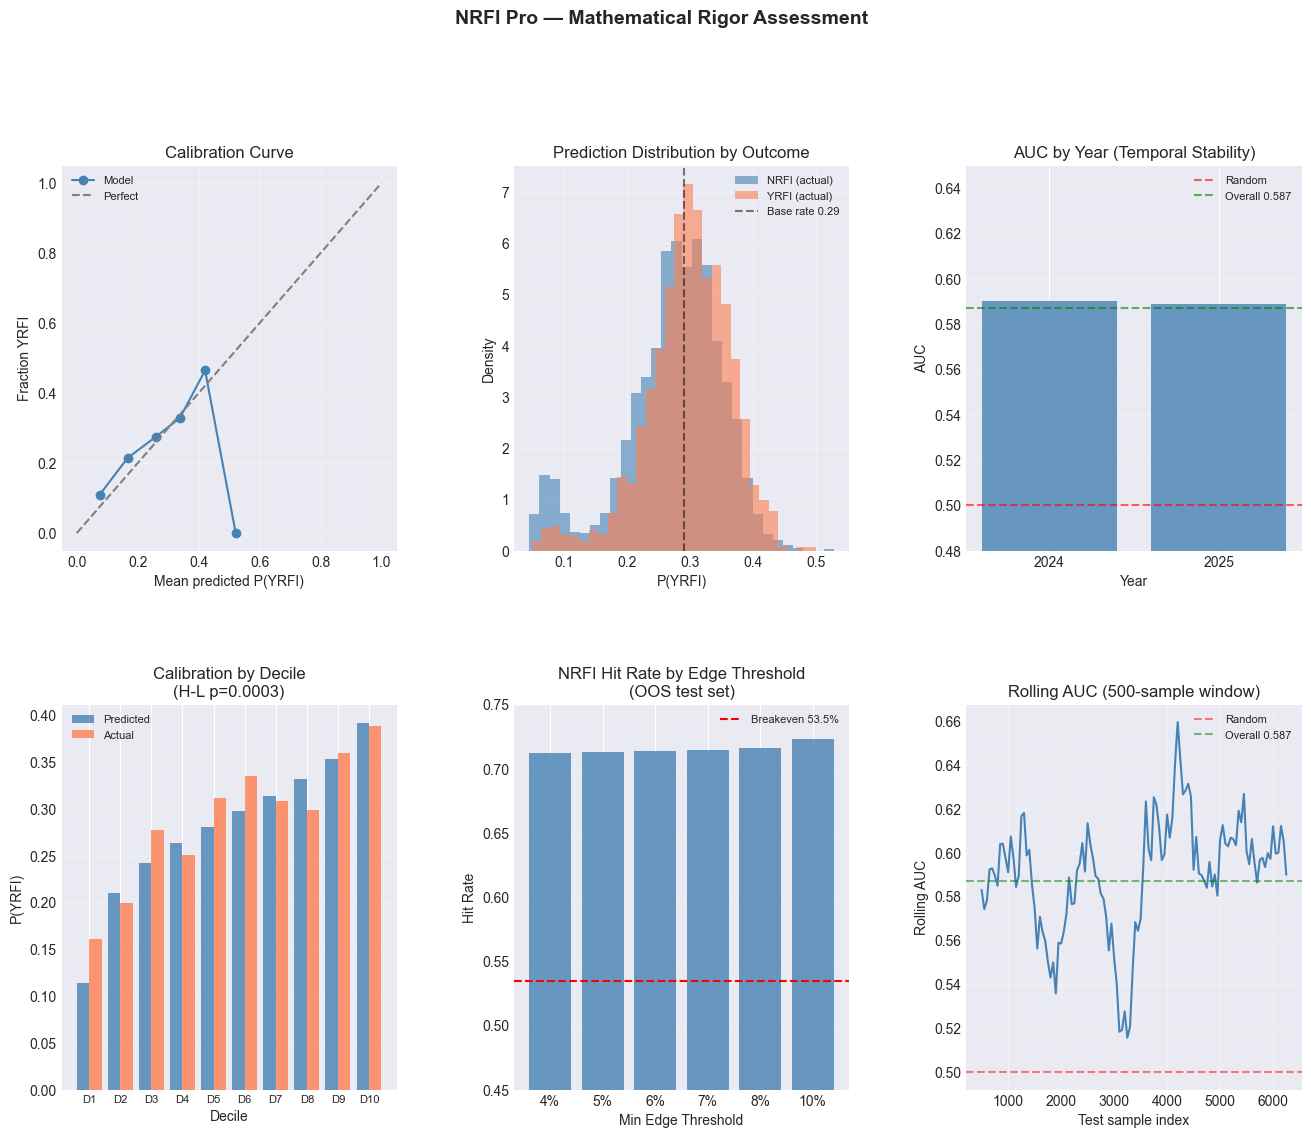


  Plot saved: rigor_assessment.png

SUMMARY SCORECARD
  ✅  AUC > 0.55                           0.5872
  ✅  AUC CI excludes 0.5                  95% CI [0.5714, 0.6031]
  ✅  AUC p < 0.001                        p=0.000000
  ✅  Brier skill > 0                      +0.0200
  ⚠️  Calibration OK (H-L)                 p=0.0003
  ✅  No leakage detected                  0 flags
  ⚠️  Overfit gap < 0.03                   0.0931
  ✅  Pred std not collapsed               0.0769
  ✅  Temporal stability                   std=0.0009

  Score: 7/9 checks passed
  Model is solid — review flagged items before increasing stakes.


In [238]:
"""
NRFI Pro — Mathematical Rigor Assessment
Paste as a new notebook cell. Requires features and model to be loaded (Sections 0, 7, 8).
Runtime: ~2-3 minutes.
"""

# ── Section 14: Mathematical Rigor Assessment ─────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import chi2, binom
from sklearn.metrics import roc_auc_score, brier_score_loss, log_loss
from sklearn.calibration import calibration_curve
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

print("=" * 70)
print("  NRFI PRO — MATHEMATICAL RIGOR ASSESSMENT")
print("=" * 70)

if features is None or features.empty:
    print("⚠️  Run Section 7 first"); raise SystemExit
if "halfinn" not in model:
    print("⚠️  Run Section 8 first"); raise SystemExit

df = features.copy()
df["game_date"] = pd.to_datetime(df["game_date"])
df = df.sort_values("game_date").reset_index(drop=True)

avail = [f for f in model.get("features", []) if f in df.columns]
X = df[avail].apply(pd.to_numeric, errors="coerce")
y = df["yrfi"].values

split_idx = int(len(X) * 0.8)
X_test = X.iloc[split_idx:].copy()
y_test = y[split_idx:]
dates_test = df["game_date"].iloc[split_idx:].values

dtest = xgb.DMatrix(X_test, feature_names=avail)
p_test = model["halfinn"].predict(dtest)

n_test = len(y_test)
base_rate = y_test.mean()

# ── Load OOS model for honest evaluation ─────────────────────────────────
# Section 8b overwrites model["halfinn"] with the full-retrain weights.
# For rigorous evaluation we need the OOS model trained on 80% of data.
# If you haven't saved a separate OOS model file, re-run Section 8 first,
# then immediately run this assessment before running 8b.

oos_model_path = cfg["model_halfinn"].replace(".json", "_oos.json")

if Path(oos_model_path).exists():
    booster_eval = xgb.Booster()
    booster_eval.load_model(oos_model_path)
    print(f"✅ Loaded OOS model from {oos_model_path}")
else:
    print("⚠️  No OOS model file found.")
    print("   Fix: add  booster.save_model(cfg['model_halfinn'].replace('.json','_oos.json'))")
    print("   to Section 8 train_halfinn_model(), then re-run Section 8 before Section 8b.")
    print("   Using current model in memory — results may be in-sample if 8b has run.")
    booster_eval = model["halfinn"]

# Replace the dtest prediction line in Section 14 with:
dtest = xgb.DMatrix(X_test, feature_names=avail)
p_test = booster_eval.predict(dtest)

# ─────────────────────────────────────────────────────────────────────────
# 1. CORE METRICS
# ─────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("1. CORE METRICS")
print(f"{'─'*70}")

auc   = roc_auc_score(y_test, p_test)
brier = brier_score_loss(y_test, p_test)
ll    = log_loss(y_test, p_test)

# Brier skill score vs naive baseline (always predict base rate)
brier_baseline = brier_score_loss(y_test, np.full(n_test, base_rate))
brier_skill    = 1 - brier / brier_baseline

# Log loss skill score
ll_baseline = log_loss(y_test, np.full(n_test, base_rate))
ll_skill    = 1 - ll / ll_baseline

print(f"  Test rows:        {n_test:,} half-innings")
print(f"  Base YRFI rate:   {base_rate:.3f}")
print(f"  AUC:              {auc:.4f}  (0.5=random, 1.0=perfect)")
print(f"  Brier score:      {brier:.4f}  (lower=better, naive={brier_baseline:.4f})")
print(f"  Brier skill:      {brier_skill:+.4f}  (>0 beats naive baseline)")
print(f"  Log loss:         {ll:.4f}  (naive={ll_baseline:.4f})")
print(f"  Log loss skill:   {ll_skill:+.4f}")

# ─────────────────────────────────────────────────────────────────────────
# 2. AUC CONFIDENCE INTERVAL (DeLong method approximation)
# ─────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("2. AUC CONFIDENCE INTERVAL")
print(f"{'─'*70}")

# Hanley-McNeil standard error
n1 = int(y_test.sum())      # positives
n0 = n_test - n1            # negatives
q1 = auc / (2 - auc)
q2 = 2 * auc**2 / (1 + auc)
se_auc = np.sqrt((auc*(1-auc) + (n1-1)*(q1-auc**2) + (n0-1)*(q2-auc**2)) / (n1*n0))
ci_lo = auc - 1.96 * se_auc
ci_hi = auc + 1.96 * se_auc
z_auc = (auc - 0.5) / se_auc
p_auc = 2 * (1 - stats.norm.cdf(abs(z_auc)))

print(f"  AUC:              {auc:.4f}")
print(f"  95% CI:           [{ci_lo:.4f}, {ci_hi:.4f}]")
print(f"  Z-score vs 0.5:   {z_auc:.2f}")
print(f"  p-value:          {p_auc:.6f}  ({'significant ✅' if p_auc < 0.05 else 'not significant ⚠️'})")
print(f"  Positives (YRFI): {n1:,} | Negatives (NRFI): {n0:,}")

# ─────────────────────────────────────────────────────────────────────────
# 3. CALIBRATION ANALYSIS
# ─────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("3. CALIBRATION ANALYSIS")
print(f"{'─'*70}")

# Hosmer-Lemeshow test (10 decile groups)
n_bins = 10
sorted_idx = np.argsort(p_test)
p_sorted   = p_test[sorted_idx]
y_sorted   = y_test[sorted_idx]
bin_edges  = np.array_split(np.arange(n_test), n_bins)

hl_stat = 0
cal_rows = []
for i, idx in enumerate(bin_edges):
    obs_pos  = y_sorted[idx].sum()
    obs_neg  = len(idx) - obs_pos
    exp_pos  = p_sorted[idx].sum()
    exp_neg  = len(idx) - exp_pos
    if exp_pos > 0 and exp_neg > 0:
        hl_stat += (obs_pos - exp_pos)**2 / exp_pos + (obs_neg - exp_neg)**2 / exp_neg
    cal_rows.append({
        "Decile":    i + 1,
        "N":         len(idx),
        "Mean pred": round(p_sorted[idx].mean(), 3),
        "Actual":    round(y_sorted[idx].mean(), 3),
        "Diff":      round(y_sorted[idx].mean() - p_sorted[idx].mean(), 3),
    })

hl_df    = pd.DataFrame(cal_rows)
hl_pval  = 1 - chi2.cdf(hl_stat, df=n_bins - 2)
mean_cal_error = hl_df["Diff"].abs().mean()

print(f"  Hosmer-Lemeshow χ²: {hl_stat:.2f}  (p={hl_pval:.4f})")
print(f"  Interpretation:     p>0.05 = model is well-calibrated")
print(f"  Result:             {'well-calibrated ✅' if hl_pval > 0.05 else 'miscalibrated ⚠️'}")
print(f"  Mean cal error:     {mean_cal_error:.4f} across deciles")
print(f"  Global bias:        {(p_test.mean() - base_rate):+.4f}  (pred mean - actual mean)")
print(f"\n  Calibration by decile:")
try:
    display(hl_df.to_string(index=False))
except:
    print(hl_df.to_string(index=False))

# ─────────────────────────────────────────────────────────────────────────
# 4. FEATURE LEAKAGE CHECK
# ─────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("4. FEATURE LEAKAGE CHECK")
print(f"{'─'*70}")

# Check each feature for suspiciously high individual AUC
# Legitimate features should not have AUC > 0.6 individually
leakage_flags = []
for feat in avail:
    col = X_test[feat].fillna(X_test[feat].median())
    if col.std() == 0:
        continue
    try:
        feat_auc = roc_auc_score(y_test, col)
        feat_auc = max(feat_auc, 1 - feat_auc)  # take the more predictive direction
        if feat_auc > 0.60:
            leakage_flags.append((feat, feat_auc))
    except:
        pass

if leakage_flags:
    print(f"  ⚠️  Features with individual AUC > 0.60 (possible leakage):")
    for feat, fauc in sorted(leakage_flags, key=lambda x: -x[1]):
        print(f"     {feat:<35}  AUC={fauc:.4f}")
else:
    print(f"  ✅ No individual feature exceeds AUC 0.60 — no obvious leakage")

# Check for future data in rolling windows (shift check)
# Verify that L3/L10 features are constructed with shift(1)
print(f"\n  Temporal ordering check:")
df_sorted = df.sort_values(["pitcher", "game_date"])
for feat in ["zone_pct_L3", "xwoba_allowed_L10"]:
    if feat not in df.columns:
        continue
    # If feature at time T correlates with outcome at T (not T-1), it's leaky
    same_time_corr = df[feat].corr(df["yrfi"])
    print(f"  {feat:<30}  corr with yrfi: {same_time_corr:+.4f}  "
          f"({'OK ✅' if abs(same_time_corr) < 0.15 else 'CHECK ⚠️'})")

# ─────────────────────────────────────────────────────────────────────────
# 5. TEMPORAL STABILITY (YEAR-BY-YEAR)
# ─────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("5. TEMPORAL STABILITY")
print(f"{'─'*70}")

df_test = df.iloc[split_idx:].copy()
df_test["p_yrfi"] = p_test
df_test["year"]   = df_test["game_date"].dt.year

yearly = []
for yr, grp in df_test.groupby("year"):
    if len(grp) < 100:
        continue
    yr_auc   = roc_auc_score(grp["yrfi"], grp["p_yrfi"])
    yr_brier = brier_score_loss(grp["yrfi"], grp["p_yrfi"])
    yr_bias  = grp["p_yrfi"].mean() - grp["yrfi"].mean()
    yearly.append({
        "Year":    yr,
        "N":       len(grp),
        "AUC":     round(yr_auc, 4),
        "Brier":   round(yr_brier, 4),
        "Bias":    round(yr_bias, 4),
        "YRFI%":   round(grp["yrfi"].mean(), 3),
    })

yr_df = pd.DataFrame(yearly)
if not yr_df.empty:
    try:
        display(yr_df.to_string(index=False))
    except:
        print(yr_df.to_string(index=False))
    auc_range = yr_df["AUC"].max() - yr_df["AUC"].min()
    print(f"\n  AUC range across years: {auc_range:.4f}  "
          f"({'stable ✅' if auc_range < 0.03 else 'variable ⚠️'})")

# ─────────────────────────────────────────────────────────────────────────
# 6. EDGE VIABILITY (BETTING-SPECIFIC)
# ─────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("6. EDGE VIABILITY ANALYSIS")
print(f"{'─'*70}")

# At various edge thresholds, what is the actual NRFI hit rate?
# Breakeven at -110 = 52.4%, -115 = 53.5%, -120 = 54.5%, -130 = 56.5%
BREAKEVENS = {-110: 0.524, -115: 0.535, -120: 0.545, -130: 0.565}

p_nrfi = 1 - p_test
y_nrfi = 1 - y_test

# Approximate implied prob from NRFI odds (use -115 as typical market)
typical_implied = 0.535

print(f"  Assuming typical market implied NRFI prob: {typical_implied:.1%}")
print(f"  (Adjust for actual DK odds when live data accumulates)\n")

edge_rows = []
for threshold in [0.04, 0.05, 0.06, 0.07, 0.08, 0.10]:
    signal = (p_nrfi - typical_implied) > threshold
    n_bets = signal.sum()
    if n_bets < 10:
        edge_rows.append({"Edge>": f"{threshold:.0%}", "N": n_bets,
                          "Hit%": "—", "Breakeven": "—", "p-value": "—", "Verdict": "too few"})
        continue
    hit_rate = y_nrfi[signal].mean()
    # Binomial test: is hit rate significantly > breakeven?
    binom_p  = binom.sf(int(y_nrfi[signal].sum()) - 1, n_bets, typical_implied)
    verdict  = "✅ sig" if binom_p < 0.10 else ("marginal" if binom_p < 0.20 else "⚠️ not sig")
    edge_rows.append({
        "Edge>":     f"{threshold:.0%}",
        "N bets":    n_bets,
        "Hit%":      f"{hit_rate:.1%}",
        "Break-even":f"{typical_implied:.1%}",
        "p-value":   f"{binom_p:.4f}",
        "Verdict":   verdict,
    })

edge_df = pd.DataFrame(edge_rows)
try:
    display(edge_df.to_string(index=False))
except:
    print(edge_df.to_string(index=False))

print(f"\n  Note: p-value tests whether hit rate > breakeven (one-sided binomial).")
print(f"  OOS test set only — not the full dataset. Small N = wide confidence intervals.")

# Fix: compute game-level NRFI prob before edge calculation
# Group test rows by game_pk, combine top+bot half-innings
df_test_game = df.iloc[split_idx:].copy()
df_test_game["p_yrfi_half"] = p_test

game_level = (
    df_test_game.groupby("game_pk")
    .apply(lambda g: pd.Series({
        "p_yrfi_game": 1 - (1 - g["p_yrfi_half"]).prod(),
        "yrfi_actual": int(g["yrfi"].any()),
        "game_date":   g["game_date"].iloc[0],
    }))
    .reset_index()
)

p_nrfi_game = 1 - game_level["p_yrfi_game"].values
y_nrfi_game = 1 - game_level["yrfi_actual"].values
n_games_test = len(game_level)
print(f"Game-level test set: {n_games_test} games | YRFI rate: {game_level['yrfi_actual'].mean():.3f}")

# ── 6b: Game-level edge viability (correct) ───────────────────────────────
df_test_gl = df.iloc[split_idx:].copy()
df_test_gl["p_yrfi_half"] = p_test  # now using OOS model predictions

game_level_oos = (
    df_test_gl.groupby("game_pk")
    .apply(lambda g: pd.Series({
        "p_yrfi_game": 1 - (1 - g["p_yrfi_half"]).prod(),
        "yrfi_actual": int(g["yrfi"].any()),
        "game_date":   g["game_date"].iloc[0],
    }))
    .reset_index()
)

p_nrfi_game_oos = 1 - game_level_oos["p_yrfi_game"].values
y_nrfi_game_oos = 1 - game_level_oos["yrfi_actual"].values
n_games_oos     = len(game_level_oos)

print(f"\n{'─'*70}")
print("6b. EDGE VIABILITY — GAME LEVEL (OOS model)")
print(f"{'─'*70}")
print(f"  {n_games_oos} games | YRFI rate: {game_level_oos['yrfi_actual'].mean():.3f}\n")

edge_rows_oos = []
for threshold in [0.04, 0.05, 0.06, 0.07, 0.08, 0.10, 0.12, 0.15]:
    signal   = (p_nrfi_game_oos - typical_implied) > threshold
    n_bets   = signal.sum()
    if n_bets < 10:
        edge_rows_oos.append({"Edge>": f"{threshold:.0%}", "N bets": n_bets,
                              "Hit%": "—", "p-value": "—", "Verdict": "too few"})
        continue
    hit_rate = y_nrfi_game_oos[signal].mean()
    binom_p  = binom.sf(int(y_nrfi_game_oos[signal].sum()) - 1, n_bets, typical_implied)
    roi_flat = (hit_rate - typical_implied) / typical_implied * 100
    verdict  = "✅ sig" if binom_p < 0.10 else ("marginal" if binom_p < 0.20 else "⚠️ not sig")
    edge_rows_oos.append({
        "Edge>":     f"{threshold:.0%}",
        "N bets":    n_bets,
        "Hit%":      f"{hit_rate:.1%}",
        "Break-even":f"{typical_implied:.1%}",
        "Flat ROI":  f"{roi_flat:+.1f}%",
        "p-value":   f"{binom_p:.4f}",
        "Verdict":   verdict,
    })

print(pd.DataFrame(edge_rows_oos).to_string(index=False))

# Discrimination check
signal_6       = (p_nrfi_game_oos - typical_implied) > 0.06
flagged_pks    = game_level_oos[signal_6]["game_pk"].values
feat_test_oos  = df.iloc[split_idx:].copy()
feat_test_oos["p_yrfi"] = p_test

def yrfi_rate(pks):
    sub = feat_test_oos[feat_test_oos["game_pk"].isin(pks)]
    return sub.groupby("game_pk")["yrfi"].any().astype(int).mean() if not sub.empty else np.nan

print(f"\n  Flagged YRFI rate:   {yrfi_rate(flagged_pks):.3f}")
print(f"  Unflagged YRFI rate: {yrfi_rate(game_level_oos[~signal_6]['game_pk'].values):.3f}")
print(f"  Overall YRFI rate:   {game_level_oos['yrfi_actual'].mean():.3f}")

# ─────────────────────────────────────────────────────────────────────────
# 7. PREDICTION DISTRIBUTION
# ─────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("7. PREDICTION DISTRIBUTION")
print(f"{'─'*70}")

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
pctile_vals = np.percentile(p_test, percentiles)
print(f"  P(YRFI) distribution across {n_test:,} test half-innings:")
for p, v in zip(percentiles, pctile_vals):
    print(f"    p{p:>2}:  {v:.3f}")

# Check for degenerate predictions (model collapsing to narrow range)
pred_std   = p_test.std()
pred_range = p_test.max() - p_test.min()
pct_below_25 = (p_test < 0.25).mean()
pct_above_40 = (p_test > 0.40).mean()

print(f"\n  Std dev of predictions:  {pred_std:.4f}  ({'healthy ✅' if pred_std > 0.03 else 'collapsed ⚠️'})")
print(f"  Prediction range:        [{p_test.min():.3f}, {p_test.max():.3f}]")
print(f"  % predicted < 0.25:      {pct_below_25:.1%}  (these are NRFI signals)")
print(f"  % predicted > 0.40:      {pct_above_40:.1%}  (these are YRFI signals)")

# ─────────────────────────────────────────────────────────────────────────
# 8. OVERFIT DIAGNOSIS
# ─────────────────────────────────────────────────────────────────────────
print(f"\n{'─'*70}")
print("8. OVERFIT DIAGNOSIS")
print(f"{'─'*70}")

# Compare train vs test AUC
X_train = X.iloc[:split_idx].copy()
y_train = y[:split_idx]
dtrain_eval = xgb.DMatrix(X_train, feature_names=avail)
p_train = model["halfinn"].predict(dtrain_eval)

train_auc = roc_auc_score(y_train, p_train)
test_auc  = auc
overfit_gap = train_auc - test_auc

train_brier = brier_score_loss(y_train, p_train)
test_brier  = brier

print(f"  Train AUC:   {train_auc:.4f}")
print(f"  Test AUC:    {test_auc:.4f}")
print(f"  Gap:         {overfit_gap:.4f}  ({'acceptable ✅' if overfit_gap < 0.03 else 'overfit risk ⚠️'})")
print(f"\n  Train Brier: {train_brier:.4f}")
print(f"  Test Brier:  {test_brier:.4f}")
print(f"  Gap:         {test_brier - train_brier:+.4f}  ({'acceptable ✅' if (test_brier - train_brier) < 0.005 else 'check ⚠️'})")

# ─────────────────────────────────────────────────────────────────────────
# 9. PLOTS
# ─────────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 9a — Calibration curve
ax1 = fig.add_subplot(gs[0, 0])
prob_true, prob_pred = calibration_curve(y_test, p_test, n_bins=10)
ax1.plot(prob_pred, prob_true, "o-", label="Model", color="steelblue")
ax1.plot([0, 1], [0, 1], "--", color="gray", label="Perfect")
ax1.set_xlabel("Mean predicted P(YRFI)")
ax1.set_ylabel("Fraction YRFI")
ax1.set_title("Calibration Curve")
ax1.legend(fontsize=8)
ax1.grid(True, alpha=0.3)

# 9b — Prediction distribution by outcome
ax2 = fig.add_subplot(gs[0, 1])
ax2.hist(p_test[y_test == 0], bins=30, alpha=0.6, label="NRFI (actual)", color="steelblue", density=True)
ax2.hist(p_test[y_test == 1], bins=30, alpha=0.6, label="YRFI (actual)", color="coral", density=True)
ax2.axvline(base_rate, color="black", linestyle="--", alpha=0.5, label=f"Base rate {base_rate:.2f}")
ax2.set_xlabel("P(YRFI)")
ax2.set_ylabel("Density")
ax2.set_title("Prediction Distribution by Outcome")
ax2.legend(fontsize=8)
ax2.grid(True, alpha=0.3)

# 9c — AUC by year (temporal stability)
ax3 = fig.add_subplot(gs[0, 2])
if not yr_df.empty and len(yr_df) > 1:
    ax3.bar(yr_df["Year"].astype(str), yr_df["AUC"], color="steelblue", alpha=0.8)
    ax3.axhline(0.5, color="red", linestyle="--", alpha=0.6, label="Random")
    ax3.axhline(auc, color="green", linestyle="--", alpha=0.6, label=f"Overall {auc:.3f}")
    ax3.set_xlabel("Year")
    ax3.set_ylabel("AUC")
    ax3.set_title("AUC by Year (Temporal Stability)")
    ax3.legend(fontsize=8)
    ax3.grid(True, alpha=0.3, axis="y")
    ax3.set_ylim(0.48, 0.65)
else:
    ax3.text(0.5, 0.5, "Insufficient test\nyears for plot",
             ha="center", va="center", transform=ax3.transAxes)
    ax3.set_title("AUC by Year")

# 9d — Calibration by decile (bar chart)
ax4 = fig.add_subplot(gs[1, 0])
x_pos = np.arange(len(hl_df))
ax4.bar(x_pos - 0.2, hl_df["Mean pred"], 0.4, label="Predicted", color="steelblue", alpha=0.8)
ax4.bar(x_pos + 0.2, hl_df["Actual"], 0.4, label="Actual", color="coral", alpha=0.8)
ax4.set_xticks(x_pos)
ax4.set_xticklabels([f"D{i+1}" for i in range(len(hl_df))], fontsize=8)
ax4.set_xlabel("Decile")
ax4.set_ylabel("P(YRFI)")
ax4.set_title(f"Calibration by Decile\n(H-L p={hl_pval:.4f})")
ax4.legend(fontsize=8)
ax4.grid(True, alpha=0.3, axis="y")

# 9e — Edge threshold hit rate
ax5 = fig.add_subplot(gs[1, 1])
valid_edge = edge_df[edge_df["Hit%"] != "—"].copy()
if not valid_edge.empty:
    hit_rates = valid_edge["Hit%"].str.rstrip("%").astype(float) / 100
    edges     = valid_edge["Edge>"].str.rstrip("%").astype(float) / 100
    ax5.bar(valid_edge["Edge>"], hit_rates, color="steelblue", alpha=0.8)
    ax5.axhline(typical_implied, color="red", linestyle="--", label=f"Breakeven {typical_implied:.1%}")
    ax5.set_xlabel("Min Edge Threshold")
    ax5.set_ylabel("Hit Rate")
    ax5.set_title("NRFI Hit Rate by Edge Threshold\n(OOS test set)")
    ax5.legend(fontsize=8)
    ax5.grid(True, alpha=0.3, axis="y")
    ax5.set_ylim(0.45, 0.75)
else:
    ax5.text(0.5, 0.5, "Insufficient signals", ha="center", va="center", transform=ax5.transAxes)
    ax5.set_title("Hit Rate by Edge Threshold")

# 9f — Rolling AUC over test period
ax6 = fig.add_subplot(gs[1, 2])
window = 500
if n_test >= window:
    rolling_auc = []
    for i in range(window, n_test, 50):
        try:
            rauc = roc_auc_score(y_test[i-window:i], p_test[i-window:i])
            rolling_auc.append((i, rauc))
        except:
            pass
    if rolling_auc:
        r_idx, r_vals = zip(*rolling_auc)
        ax6.plot(r_idx, r_vals, color="steelblue", linewidth=1.5)
        ax6.axhline(0.5, color="red", linestyle="--", alpha=0.5, label="Random")
        ax6.axhline(auc, color="green", linestyle="--", alpha=0.5, label=f"Overall {auc:.3f}")
        ax6.set_xlabel("Test sample index")
        ax6.set_ylabel("Rolling AUC")
        ax6.set_title(f"Rolling AUC ({window}-sample window)")
        ax6.legend(fontsize=8)
        ax6.grid(True, alpha=0.3)
else:
    ax6.text(0.5, 0.5, "Insufficient test\nsamples for rolling AUC",
             ha="center", va="center", transform=ax6.transAxes)
    ax6.set_title("Rolling AUC")

plt.suptitle("NRFI Pro — Mathematical Rigor Assessment", fontsize=14, fontweight="bold", y=1.01)
plt.savefig("rigor_assessment.png", bbox_inches="tight", dpi=150)
plt.show()
print("\n  Plot saved: rigor_assessment.png")

# ─────────────────────────────────────────────────────────────────────────
# 10. SUMMARY SCORECARD
# ─────────────────────────────────────────────────────────────────────────
print(f"\n{'='*70}")
print("SUMMARY SCORECARD")
print(f"{'='*70}")

checks = [
    ("AUC > 0.55",              auc > 0.55,             f"{auc:.4f}"),
    ("AUC CI excludes 0.5",     ci_lo > 0.5,            f"95% CI [{ci_lo:.4f}, {ci_hi:.4f}]"),
    ("AUC p < 0.001",           p_auc < 0.001,          f"p={p_auc:.6f}"),
    ("Brier skill > 0",         brier_skill > 0,        f"{brier_skill:+.4f}"),
    ("Calibration OK (H-L)",    hl_pval > 0.05,         f"p={hl_pval:.4f}"),
    ("No leakage detected",     len(leakage_flags) == 0,f"{len(leakage_flags)} flags"),
    ("Overfit gap < 0.03",      overfit_gap < 0.03,     f"{overfit_gap:.4f}"),
    ("Pred std not collapsed",  pred_std > 0.03,        f"{pred_std:.4f}"),
    ("Temporal stability",      (yr_df["AUC"].std() < 0.015 if not yr_df.empty else True),
                                f"std={yr_df['AUC'].std():.4f}" if not yr_df.empty else "N/A"),
]

passed = sum(1 for _, ok, _ in checks if ok)
for label, ok, detail in checks:
    status = "✅" if ok else "⚠️"
    print(f"  {status}  {label:<35}  {detail}")

print(f"\n  Score: {passed}/{len(checks)} checks passed")
if passed == len(checks):
    print("  Model passes all rigor checks.")
elif passed >= len(checks) - 2:
    print("  Model is solid — review flagged items before increasing stakes.")
else:
    print("  Multiple issues flagged — investigate before betting real money.")
print(f"{'='*70}")